In [1]:
import numpy as np
import tensorflow as tf
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt

In [2]:
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv('enhanced_dataset.csv')
df.tail()

,date,year,month,day,dayofweek,is_weekend,dayofyear,month_sin,month_cos,dayofyear_sin,...,relative_humidity_2m_max__lag_7,relative_humidity_2m_max__rolling_mean_7d,relative_humidity_2m_max__rolling_std_7d,relative_humidity_2m_max__7day_trend,cloud_rain_interaction,temp_humidity_interaction,precip_cloud_interaction,cloud_volatility_7d,rain_volatility_7d,temp_seasonal_anomaly
9247,2025-04-26,2025,4,26,5,True,116,0.866025,-0.5,0.911169,...,81.0,85.142857,5.843189,9.0,0.0,330.0,0.0,23.027933,15.102065,-2.538462
9248,2025-04-27,2025,4,27,6,True,117,0.866025,-0.5,0.903946,...,91.0,85.714286,6.651172,4.0,330.0,285.6,300.0,23.483530,15.023077,-3.503846
9249,2025-04-28,2025,4,28,0,False,118,0.866025,-0.5,0.896456,...,91.0,85.571429,6.528327,-1.0,288.0,270.6,480.0,23.107410,1.521747,-3.942308
9250,2025-04-29,2025,4,29,1,False,119,0.866025,-0.5,0.888701,...,80.0,87.571429,6.679749,14.0,460.0,329.0,1200.0,22.867111,1.978576,-4.903846
9251,2025-04-30,2025,4,30,2,False,120,0.866025,-0.5,0.880683,...,84.0,89.428571,7.299706,13.0,0.0,524.4,0.0,23.229702,2.003212,-1.792308


**Option 15 : Predicting each variable using a seperated model**

1- Predicting the max temp

In [3]:
class TemperatureMaxLSTM:
    def __init__(self, df, sequence_length=10, forecast_horizon=3):
        """
        Dedicated LSTM model for temperature and humidity prediction
        """
        self.df = df.copy()
        self.sequence_length = sequence_length
        self.forecast_horizon = forecast_horizon
        self.scaler_features = None
        self.scaler_targets = None
        self.model = None
        
        # Temperature and humidity target columns
        self.target_cols = [
            'temperature_2m_max (°C)'
        ]
        
    def preprocess_data(self):
        """Preprocess data specifically for max temperature prediction"""
        print("🧹 Preprocessing data for max temperature prediction...")
        df = self.df.copy()
        
        # Check which target columns are available
        available_targets = [col for col in self.target_cols if col in df.columns]
        if not available_targets:
            raise ValueError(f"None of the target columns {self.target_cols} found in the dataframe")
        
        self.available_targets = available_targets
        print(f"Available target columns: {available_targets}")
        
        # Handle missing values for targets
        for col in available_targets:
            df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
            df[col] = df[col].interpolate(method='linear')
            df[col].fillna(df[col].median(), inplace=True)
        
        # Remove rows with any missing target values
        df = df.dropna(subset=available_targets)
        
        # Define feature columns (exclude date, weather_condition, and target columns)
        exclude_cols = ['date', 'weather_condition'] + available_targets
        feature_cols = [col for col in df.columns if col not in exclude_cols]
        
        # Handle missing values for features
        numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
            df[col] = df[col].interpolate(method='linear')
            df[col].fillna(df[col].median(), inplace=True)
        
        # Scale features
        self.scaler_features = StandardScaler()
        df[feature_cols] = self.scaler_features.fit_transform(df[feature_cols])
        
        # Scale targets
        self.scaler_targets = StandardScaler()
        df[available_targets] = self.scaler_targets.fit_transform(df[available_targets])
        
        # Store processed data
        self.df_processed = df
        self.feature_cols = feature_cols
        
        print(f"Feature columns ({len(feature_cols)}): {feature_cols[:5]}..." if len(feature_cols) > 5 else f"Feature columns: {feature_cols}")
        print(f"Target columns: {available_targets}")
        print(f"Data shape after preprocessing: {df.shape}")
        
        return df
    
    def create_sequences(self):
        """Create sequences for Maximum temperatureprediction"""
        print(f"🪟 Creating sequences for Maximum temperature prediction...")
        
        X, y = [], []
        data = self.df_processed
        features = data[self.feature_cols].values
        targets = data[self.available_targets].values
        
        # Create sequences with sliding window
        for i in range(len(data) - self.sequence_length - self.forecast_horizon + 1):
            # Input sequence
            X_seq = features[i:i + self.sequence_length]
            
            # Target sequence (next forecast_horizon days)
            y_seq = targets[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            X.append(X_seq)
            y.append(y_seq)
        
        X = np.array(X)
        y = np.array(y)
        
        print(f"Created sequences: X={X.shape}, y={y.shape}")
        print(f"Input sequence length: {self.sequence_length}")
        print(f"Forecast horizon: {self.forecast_horizon}")
        print(f"Number of features: {X.shape[2]}")
        print(f"Number of target variables: {y.shape[2]}")
        
        return X, y
    
    def build_model(self, input_shape, output_shape):
        """Build LSTM model for Maximum temperature prediction"""
        model = Sequential([
            # First LSTM layer
            LSTM(128, return_sequences=True, input_shape=input_shape,
                 kernel_regularizer=l2(0.001), dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            
            # Second LSTM layer
            LSTM(64, return_sequences=True,
                 kernel_regularizer=l2(0.001), dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            
            # Third LSTM layer
            LSTM(32, return_sequences=False,
                 kernel_regularizer=l2(0.001), dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            Dropout(0.3),
            
            # Dense layers for multi-step prediction
            Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.3),
            
            Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
            Dropout(0.2),
            
            # Output layer - predict all forecast steps and variables at once
            Dense(output_shape[0] * output_shape[1], activation='linear'),
            
            # Reshape to (forecast_horizon, num_target_variables)
            tf.keras.layers.Reshape(output_shape)
        ])
        
        return model
    
    def train_model(self, validation_split=0.2, epochs=150, batch_size=32):
        """Train the temperature Max LSTM model"""
        print("\n" + "="*70)
        print("TRAINING TEMPERATURE MAX LSTM MODEL")
        print("="*70)
        
        # Create sequences
        X, y = self.create_sequences()
        
        if len(X) == 0:
            raise ValueError("No sequences created!")
        
        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, shuffle=True
        )
        
        print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
        
        # Build model
        input_shape = (self.sequence_length, X.shape[2])
        output_shape = (self.forecast_horizon, len(self.available_targets))
        
        self.model = self.build_model(input_shape, output_shape)
        
        # Compile model
        self.model.compile(
            optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
            loss='mse',
            metrics=['mae']
        )
        
        print(f"\nModel architecture:")
        self.model.summary()
        
        # Callbacks
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7, verbose=1)
        ]
        
        # Train model
        print(f"\nTraining model...")
        history = self.model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=validation_split,
            callbacks=callbacks,
            verbose=1
        )
        
        # Evaluate
        print(f"\nEvaluating model...")
        y_pred = self.model.predict(X_test, verbose=0)
        
        return self.evaluate_model(y_test, y_pred, history)
    
    def evaluate_model(self, y_true, y_pred, history):
        """Evaluate the temperature max model"""
        print("\n" + "="*70)
        print("TEMPERATURE MAX LSTM RESULTS")
        print("="*70)
        
        # Inverse transform predictions and true values to original scale
        y_true_original = np.zeros_like(y_true)
        y_pred_original = np.zeros_like(y_pred)
        
        for day in range(self.forecast_horizon):
            y_true_original[:, day, :] = self.scaler_targets.inverse_transform(y_true[:, day, :])
            y_pred_original[:, day, :] = self.scaler_targets.inverse_transform(y_pred[:, day, :])
        
        # Calculate metrics for each target variable and forecast day
        results = {}
        
        for i, target_name in enumerate(self.available_targets):
            print(f"\n🌡️ {target_name}:")
            print("-" * 50)
            
            target_results = {
                'mae': [],
                'rmse': [],
                'r2': [],
                'mape': []
            }
            
            for day in range(self.forecast_horizon):
                y_true_day = y_true_original[:, day, i]
                y_pred_day = y_pred_original[:, day, i]
                
                mae = mean_absolute_error(y_true_day, y_pred_day)
                rmse = np.sqrt(mean_squared_error(y_true_day, y_pred_day))
                r2 = r2_score(y_true_day, y_pred_day)
                
                # Calculate MAPE (Mean Absolute Percentage Error)
                mape = np.mean(np.abs((y_true_day - y_pred_day) / (y_true_day + 1e-8))) * 100
                
                target_results['mae'].append(mae)
                target_results['rmse'].append(rmse)
                target_results['r2'].append(r2)
                target_results['mape'].append(mape)
                
                print(f"  Day {day+1}: MAE={mae:.3f}, RMSE={rmse:.3f}, R²={r2:.3f}, MAPE={mape:.2f}%")
            
            # Calculate averages
            avg_mae = np.mean(target_results['mae'])
            avg_rmse = np.mean(target_results['rmse'])
            avg_r2 = np.mean(target_results['r2'])
            avg_mape = np.mean(target_results['mape'])
            
            target_results['avg_mae'] = avg_mae
            target_results['avg_rmse'] = avg_rmse
            target_results['avg_r2'] = avg_r2
            target_results['avg_mape'] = avg_mape
            
            print(f"  Average: MAE={avg_mae:.3f}, RMSE={avg_rmse:.3f}, R²={avg_r2:.3f}, MAPE={avg_mape:.2f}%")
            
            results[target_name] = target_results
        
        # Overall performance summary
        print(f"\n📊 OVERALL PERFORMANCE SUMMARY:")
        print("="*50)
        
        all_maes = [results[target]['avg_mae'] for target in self.available_targets]
        all_rmses = [results[target]['avg_rmse'] for target in self.available_targets]
        all_r2s = [results[target]['avg_r2'] for target in self.available_targets]
        all_mapes = [results[target]['avg_mape'] for target in self.available_targets]
        
        print(f"Overall Average MAE: {np.mean(all_maes):.3f}")
        print(f"Overall Average RMSE: {np.mean(all_rmses):.3f}")
        print(f"Overall Average R²: {np.mean(all_r2s):.3f}")
        print(f"Overall Average MAPE: {np.mean(all_mapes):.2f}%")
        
        # Best and worst performing variables
        best_target = min(results.keys(), key=lambda x: results[x]['avg_mae'])
        worst_target = max(results.keys(), key=lambda x: results[x]['avg_mae'])
        
        print(f"\n🏆 Best performing variable: {best_target} (MAE: {results[best_target]['avg_mae']:.3f})")
        print(f"⚠️  Worst performing variable: {worst_target} (MAE: {results[worst_target]['avg_mae']:.3f})")
        
        return results, history, y_true_original, y_pred_original
    
    def predict_future(self, recent_data, days_ahead=None):
        """Predict temperature max for future days"""
        if days_ahead is None:
            days_ahead = self.forecast_horizon
        
        if isinstance(recent_data, pd.DataFrame):
            # Ensure recent_data has the same preprocessing
            recent_scaled = self.scaler_features.transform(recent_data[self.feature_cols])
        else:
            recent_scaled = recent_data
        
        # Use the last sequence_length days as input
        input_seq = recent_scaled[-self.sequence_length:].reshape(1, self.sequence_length, -1)
        
        # Make prediction
        prediction_scaled = self.model.predict(input_seq, verbose=0)
        
        # Inverse transform to original scale
        prediction_original = np.zeros_like(prediction_scaled)
        for day in range(self.forecast_horizon):
            prediction_original[0, day, :] = self.scaler_targets.inverse_transform(
                prediction_scaled[0, day, :].reshape(1, -1)
            )
        
        # Create results dictionary
        results = {}
        for i, target_name in enumerate(self.available_targets):
            results[target_name] = prediction_original[0, :days_ahead, i]
        
        return results
    
    def plot_training_history(self, history):
        """Plot training history"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Loss
        ax1.plot(history.history['loss'], label='Training Loss')
        ax1.plot(history.history['val_loss'], label='Validation Loss')
        ax1.set_title('Model Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()
        
        # MAE
        ax2.plot(history.history['mae'], label='Training MAE')
        ax2.plot(history.history['val_mae'], label='Validation MAE')
        ax2.set_title('Model MAE')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('MAE')
        ax2.legend()
        
        plt.tight_layout()
        plt.show()

🌡️ DEDICATED MAXIMUM TEMPERATURE LSTM FORECASTING
🧹 Preprocessing data for max temperature prediction...
Available target columns: ['temperature_2m_max (°C)']
Feature columns (147): ['year', 'month', 'day', 'dayofweek', 'is_weekend']...
Target columns: ['temperature_2m_max (°C)']
Data shape after preprocessing: (9252, 150)

TRAINING TEMPERATURE MAX LSTM MODEL
🪟 Creating sequences for Maximum temperature prediction...
Created sequences: X=(9240, 10, 147), y=(9240, 3, 1)
Input sequence length: 10
Forecast horizon: 3
Number of features: 147
Number of target variables: 1
Training samples: 7392, Test samples: 1848

Model architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 128)        │       141,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 3, 1)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 208,579 (814.76 KB)

 Trainable params: 208,003 (812.51 KB)

 Non-trainable params: 576 (2.25 KB)


Training model...
Epoch 1/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - loss: 2.2942 - mae: 1.0142 - val_loss: 1.1626 - val_mae: 0.6411 - learning_rate: 0.0010
Epoch 2/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 1.1731 - mae: 0.6230 - val_loss: 0.8560 - val_mae: 0.4515 - learning_rate: 0.0010
Epoch 3/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.9526 - mae: 0.5213 - val_loss: 0.7100 - val_mae: 0.3757 - learning_rate: 0.0010
Epoch 4/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.8125 - mae: 0.4719 - val_loss: 0.6386 - val_mae: 0.3642 - learning_rate: 0.0010
Epoch 5/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.7227 - mae: 0.4453 - val_loss: 0.5683 - val_mae: 0.3514 - learning_rate: 0.0010
Epoch 6/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.6419 - mae: 0.4188 - val_loss: 0.5141 - val_mae: 0.3344 - learning_rate: 0.0010
Epoch 7/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.5810 - mae: 0.4040 - val_loss: 0.4738 - val_mae: 0.3336 - learning

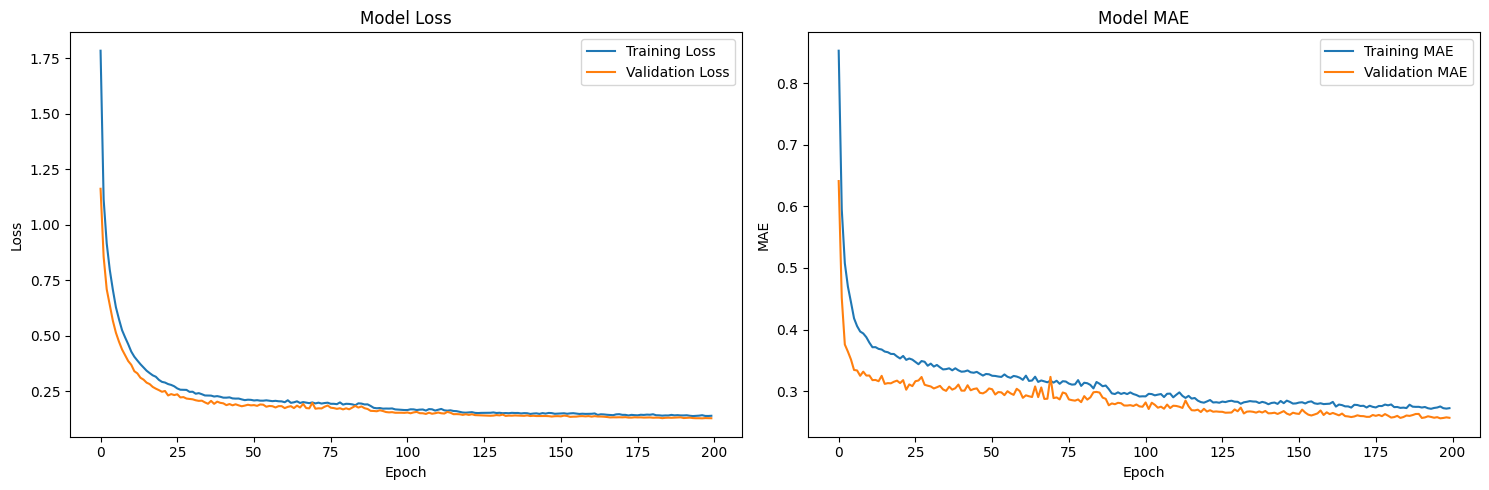

In [4]:
def run_temperature_humidity_forecasting(df):
    """Run dedicated temperature forecasting"""
    print("🌡️ DEDICATED MAXIMUM TEMPERATURE LSTM FORECASTING")
    print("=" * 70)
    
    # Initialize model
    model = TemperatureMaxLSTM(df, sequence_length=10, forecast_horizon=3)
    
    # Preprocess data
    model.preprocess_data()
    
    # Train model
    results, history, y_true, y_pred = model.train_model(
        validation_split=0.2, 
        epochs=200, 
        batch_size=64
    )
    
    # Plot training history
    model.plot_training_history(history)
    
    return model, results, history, y_true, y_pred

# Usage example:
model, results, history, y_true, y_pred = run_temperature_humidity_forecasting(df)


🔮 Making 3-day Maximum temperature forecast...
--------------------------------------------------
📅 3-Day Maximum Temperature Forecast:
  Thursday   (2025-05-01):
     🌡️ temperature_2m_max (°C): 31.72
  Friday     (2025-05-02):
     🌡️ temperature_2m_max (°C): 31.76
  Saturday   (2025-05-03):
     🌡️ temperature_2m_max (°C): 31.60


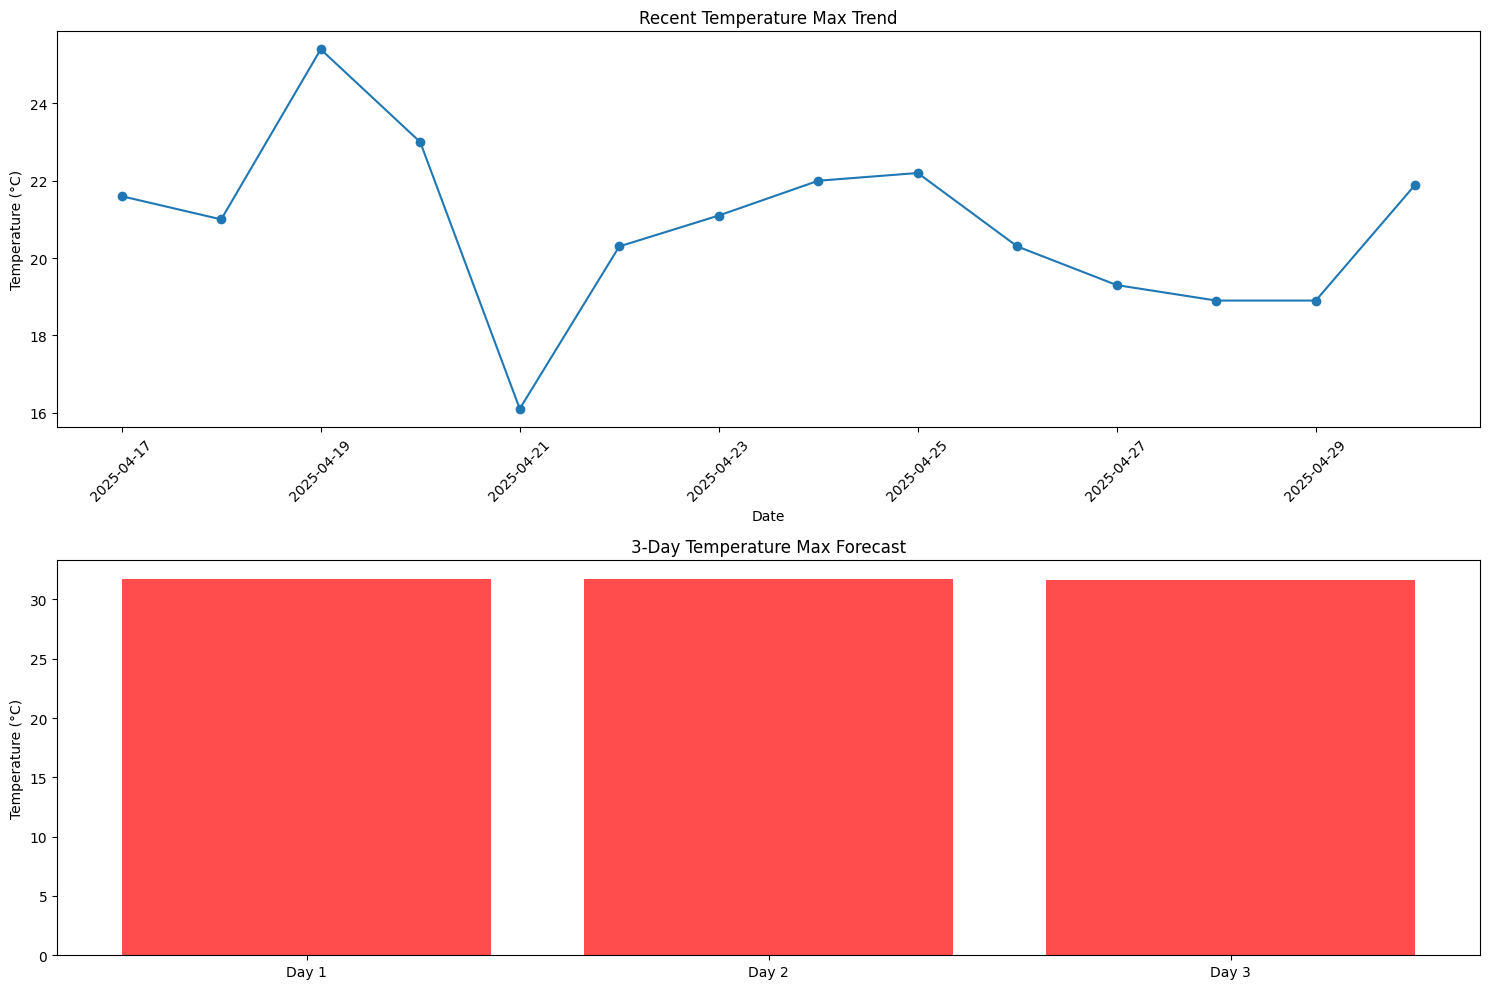

In [5]:
def make_predictions_and_visualize(model, df):
    """Make predictions and create visualizations for max temperature only"""
    import matplotlib.pyplot as plt
    from datetime import timedelta
    import pandas as pd
    import numpy as np
    
    print("\n🔮 Making 3-day Maximum temperature forecast...")
    print("-" * 50)
    
    # Get only the features used during training
    feature_cols = model.feature_cols

    # Pull only the last `sequence_length` rows
    recent_data = df[feature_cols].tail(model.sequence_length).copy()

    # Ensure numeric and same dtype
    recent_data = recent_data.apply(pd.to_numeric, errors='coerce').dropna()

    # If any rows dropped, re-pad from the top
    if len(recent_data) < model.sequence_length:
        padding_needed = model.sequence_length - len(recent_data)
        padding = np.zeros((padding_needed, len(feature_cols)))
        recent_data = np.vstack([padding, recent_data.values])
    else:
        recent_data = recent_data.values

    # Final shape must be (1, sequence_length, num_features)
    recent_data = recent_data.reshape(1, model.sequence_length, len(feature_cols)).astype(np.float32)

    try:
        # Get temperature/humidity predictions
        temp_humidity_results = model.predict_future(recent_data)
        
        # Get next 3 days
        last_date = pd.to_datetime(df['date']).max()
        next_3_dates = [last_date + timedelta(days=i+1) for i in range(3)]
        days_and_dates = [(d.strftime('%A'), d.strftime('%Y-%m-%d')) for d in next_3_dates]
        
        print("📅 3-Day Maximum Temperature Forecast:")
        for i, (day, date) in enumerate(days_and_dates):
            print(f"  {day:10} ({date}):")
            for target_name in model.available_targets:
                try:
                    value = temp_humidity_results[target_name][i]
                    print(f"     🌡️ {target_name}: {value:.2f}")
                except (IndexError, TypeError) as e:
                    print(f"     ❌ Error with {target_name}: {e}")

        
        # Visualization
        fig, axes = plt.subplots(2, 1, figsize=(15, 10))
        
        # Plot recent temperature trends
        if 'temperature_2m_max (°C)' in df.columns:
            recent_temp = df[['date', 'temperature_2m_max (°C)']].tail(14)
            recent_temp['date'] = pd.to_datetime(recent_temp['date'])
            axes[0].plot(recent_temp['date'], recent_temp['temperature_2m_max (°C)'], 'o-')
            axes[0].set_title('Recent Temperature Max Trend')
            axes[0].set_xlabel('Date')
            axes[0].set_ylabel('Temperature (°C)')
            axes[0].tick_params(axis='x', rotation=45)
        
        # Plot forecast temperature
        forecast_days = [f"Day {i+1}" for i in range(3)]
        if 'temperature_2m_max (°C)' in temp_humidity_results:
            temp_forecast = temp_humidity_results['temperature_2m_max (°C)']
            axes[1].bar(forecast_days, temp_forecast, color='red', alpha=0.7)
            axes[1].set_title('3-Day Temperature Max Forecast')
            axes[1].set_ylabel('Temperature (°C)')
        
        plt.tight_layout()
        plt.show()
        
        return temp_humidity_results
        
    except Exception as e:
        print(f"❌ Prediction error: {e}")
        return None


# Usage example:

predictions = make_predictions_and_visualize(model, df)

🌡️ MAXIMUM TEMPERATURE PREDICTIONS

📅 Test Sequence 1:
------------------------------------------------------------

🌡️  temperature_2m_max (°C):
----------------------------------------
  Day |     Actual |  Predicted |      Error |    % Error
------------------------------------------------------------
    1 |      35.00 |      35.46 |       0.46 |       1.3%
    2 |      35.50 |      35.49 |       0.01 |       0.0%
    3 |      37.80 |      35.20 |       2.60 |       6.9%
------------------------------------------------------------
Sequence MAE: 1.023

📅 Test Sequence 2:
------------------------------------------------------------

🌡️  temperature_2m_max (°C):
----------------------------------------
  Day |     Actual |  Predicted |      Error |    % Error
------------------------------------------------------------
    1 |      27.00 |      27.81 |       0.81 |       3.0%
    2 |      29.90 |      27.90 |       2.00 |       6.7%
    3 |      33.70 |      27.94 |       5.76 |      

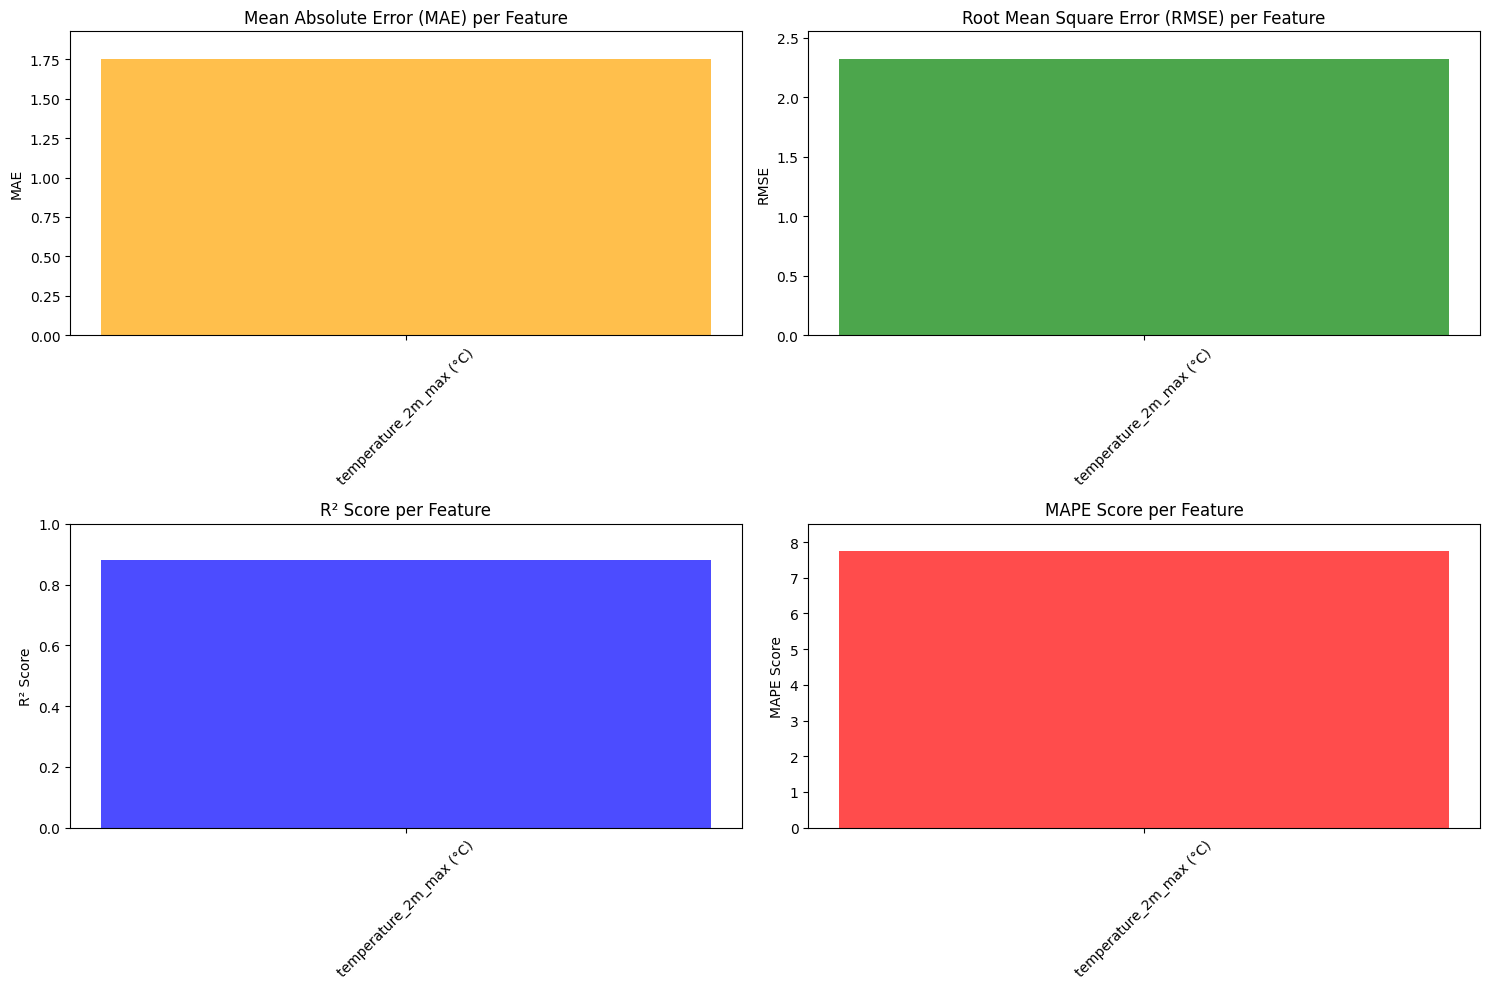


🏆 PERFORMANCE SUMMARY:
Best performing feature: temperature_2m_max (°C) (MAE: 1.752)
Worst performing feature: temperature_2m_max (°C) (MAE: 1.752)
Overall average MAE: 1.752
Overall average RMSE: 2.320
Overall average R²: 0.882


In [7]:
def show_regression_predictions(
    model, 
    y_true, 
    y_pred, 
    num_samples=5
):
    """Display temperature regression predictions only."""
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    print("🌡️ MAXIMUM TEMPERATURE PREDICTIONS")
    print("=" * 60)

    sample_size = min(num_samples, len(y_true))

    # Get feature names from the model
    feature_names = model.available_targets if hasattr(model, 'available_targets') else [f"Feature {i}" for i in range(y_true.shape[2])]

    # Display sample predictions
    for i in range(sample_size):
        print(f"\n📅 Test Sequence {i+1}:")
        print("-" * 60)

        # Create a nice table format for each feature
        for f, feature_name in enumerate(feature_names):
            print(f"\n🌡️  {feature_name}:")
            print("-" * 40)
            print(f"{'Day':>5} | {'Actual':>10} | {'Predicted':>10} | {'Error':>10} | {'% Error':>10}")
            print("-" * 60)

            mae_sequence = 0
            for day in range(model.forecast_horizon):
                actual = y_true[i, day, f]
                predicted = y_pred[i, day, f]
                error = abs(actual - predicted)
                percent_error = (error / (abs(actual) + 1e-8)) * 100
                mae_sequence += error

                print(f"{day+1:>5} | {actual:>10.2f} | {predicted:>10.2f} | {error:>10.2f} | {percent_error:>9.1f}%")

            mae_sequence /= model.forecast_horizon
            print("-" * 60)
            print(f"Sequence MAE: {mae_sequence:.3f}")

    # Overall statistics for temperature and humidity
    print(f"\n📊 OVERALL REGRESSION STATISTICS:")
    print("=" * 50)

    num_features = y_true.shape[2]

    for f, feature_name in enumerate(feature_names):
        print(f"\n🌡️  {feature_name}:")
        print("-" * 30)
        
        # Calculate metrics for this feature
        y_true_flat = y_true[:, :, f].flatten()
        y_pred_flat = y_pred[:, :, f].flatten()
        
        mae = mean_absolute_error(y_true_flat, y_pred_flat)
        rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
        r2 = r2_score(y_true_flat, y_pred_flat)
        mape = np.mean(np.abs((y_true_flat - y_pred_flat) / (y_true_flat + 1e-8))) * 100
        
        print(f"  MAE:  {mae:.3f}")
        print(f"  RMSE: {rmse:.3f}")
        print(f"  R²:   {r2:.3f}")
        print(f"  MAPE: {mape:.2f}%")
        
        # Per-day accuracy for this feature
        print(f"\n  📈 Daily Performance:")
        for day in range(model.forecast_horizon):
            day_true = y_true[:, day, f]
            day_pred = y_pred[:, day, f]
            day_mae = mean_absolute_error(day_true, day_pred)
            day_rmse = np.sqrt(mean_squared_error(day_true, day_pred))
            day_r2 = r2_score(day_true, day_pred)
            print(f"    Day {day+1}: MAE={day_mae:.3f}, RMSE={day_rmse:.3f}, R²={day_r2:.3f}")

    # Create visualization
    print(f"\n📈 CREATING PERFORMANCE VISUALIZATION...")
    
    # Calculate metrics for plotting
    maes = []
    rmses = []
    r2s = []
    mape = []
    
    for f in range(num_features):
        y_true_flat = y_true[:, :, f].flatten()
        y_pred_flat = y_pred[:, :, f].flatten()
        
        maes.append(mean_absolute_error(y_true_flat, y_pred_flat))
        rmses.append(np.sqrt(mean_squared_error(y_true_flat, y_pred_flat)))
        r2s.append(r2_score(y_true_flat, y_pred_flat))
        mape.append(np.mean(np.abs((y_true_flat - y_pred_flat) / (y_true_flat + 1e-8))) * 100)

    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # MAE plot
    axes[0, 0].bar(feature_names, maes, color='orange', alpha=0.7)
    axes[0, 0].set_title("Mean Absolute Error (MAE) per Feature")
    axes[0, 0].set_ylabel("MAE")
    axes[0, 0].set_ylim(0, max(maes) * 1.1)
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # RMSE plot
    axes[0, 1].bar(feature_names, rmses, color='green', alpha=0.7)
    axes[0, 1].set_title("Root Mean Square Error (RMSE) per Feature")
    axes[0, 1].set_ylabel("RMSE")
    axes[0, 1].set_ylim(0, max(rmses) * 1.1)
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # R² plot
    axes[1, 0].bar(feature_names, r2s, color='blue', alpha=0.7)
    axes[1, 0].set_title("R² Score per Feature")
    axes[1, 0].set_ylabel("R² Score")
    axes[1, 0].set_ylim(0, max(1.0, max(r2s) * 1.1))
    axes[1, 0].tick_params(axis='x', rotation=45)
    

    axes[1, 1].bar(feature_names, mape, color='red', alpha=0.7)
    axes[1, 1].set_title("MAPE Score per Feature")
    axes[1, 1].set_ylabel("MAPE Score")
    axes[1, 1].set_ylim(0, max(mape) * 1.1)
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    
    plt.tight_layout()
    plt.show()

    # Summary statistics
    print(f"\n🏆 PERFORMANCE SUMMARY:")
    print("=" * 30)
    print(f"Best performing feature: {feature_names[np.argmin(maes)]} (MAE: {min(maes):.3f})")
    print(f"Worst performing feature: {feature_names[np.argmax(maes)]} (MAE: {max(maes):.3f})")
    print(f"Overall average MAE: {np.mean(maes):.3f}")
    print(f"Overall average RMSE: {np.mean(rmses):.3f}")
    print(f"Overall average R²: {np.mean(r2s):.3f}")


# Usage example - replace your original function call with this:
show_regression_predictions(
    model, 
    y_true, 
    y_pred, 
    num_samples=3
)

In [8]:
def save_lstm_model(model, model_name="TemperatureMaxLSTM", save_dir="saved_models"):
    import os
    import json
    import pickle
    from datetime import datetime
    import joblib

    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_folder = f"{save_dir}/{model_name.replace(' ', '_')}_{timestamp}"
    os.makedirs(model_folder, exist_ok=True)

    print(f"💾 Saving '{model_name}' to: {model_folder}")
    print("=" * 60)

    try:
        # 1. Save the Keras model
        model_path = f"{model_folder}/keras_model.keras"
        model.model.save(model_path)
        print("✅ Keras model saved.")

        # 2. Save scalers
        joblib.dump(model.scaler_features, f"{model_folder}/scaler_features.pkl")
        joblib.dump(model.scaler_targets, f"{model_folder}/scaler_targets.pkl")
        print("✅ Scalers saved.")

        # 3. Save config
        config = {
            'model_name': model_name,
            'sequence_length': model.sequence_length,
            'forecast_horizon': model.forecast_horizon,
            'available_targets': model.available_targets,
            'feature_columns': model.feature_cols,
            'timestamp': timestamp,
            'model_type': 'TemperatureHumidityLSTM',
            'framework': 'TensorFlow/Keras'
        }
        with open(f"{model_folder}/model_config.json", 'w') as f:
            json.dump(config, f, indent=4)
        print("✅ Model configuration saved.")

        # 4. Save model object (without keras model to avoid issues)
        model_copy = model.__dict__.copy()
        model_copy.pop('model', None)
        with open(f"{model_folder}/full_model.pkl", 'wb') as f:
            pickle.dump(model_copy, f)
        print("✅ Full model object saved.")

        return model_folder

    except Exception as e:
        print(f"❌ Error saving model: {e}")
        return None



def load_lstm_model(model_folder):
    import os
    import json
    import pickle
    import joblib
    from tensorflow.keras.models import load_model

    try:
        print(f"📂 Loading model from: {model_folder}")

        # Load keras model
        keras_model = load_model(f"{model_folder}/keras_model.keras")

        # Load scalers
        scaler_features = joblib.load(f"{model_folder}/scaler_features.pkl")
        scaler_targets = joblib.load(f"{model_folder}/scaler_targets.pkl")

        # Load config
        with open(f"{model_folder}/model_config.json", 'r') as f:
            config = json.load(f)

        # Load full model dict
        with open(f"{model_folder}/full_model.pkl", 'rb') as f:
            model_dict = pickle.load(f)

        # Create empty model object
        model = TemperatureMaxLSTM(pd.DataFrame(), config['sequence_length'], config['forecast_horizon'])
        model.model = keras_model
        model.scaler_features = scaler_features
        model.scaler_targets = scaler_targets

        # Restore other attributes
        for key, value in model_dict.items():
            setattr(model, key, value)

        print(f"✅ Model '{config['model_name']}' successfully loaded!")
        return model

    except Exception as e:
        print(f"❌ Error loading model: {e}")
        return None


model_folder = save_lstm_model(model, model_name="MaximumTemperatureLSTM_Model1")

💾 Saving 'MaximumTemperatureLSTM_Model1' to: saved_models/MaximumTemperatureLSTM_Model1_20250706_160704
✅ Keras model saved.
✅ Scalers saved.
✅ Model configuration saved.
✅ Full model object saved.


2- Predicting the min temp

In [9]:
class TemperatureMinLSTM:
    def __init__(self, df, sequence_length=10, forecast_horizon=3):
        """
        Dedicated LSTM model for temperature and humidity prediction
        """
        self.df = df.copy()
        self.sequence_length = sequence_length
        self.forecast_horizon = forecast_horizon
        self.scaler_features = None
        self.scaler_targets = None
        self.model = None
        
        # Temperature and humidity target columns
        self.target_cols = [
            'temperature_2m_min (°C)'
        ]
        
    def preprocess_data(self):
        """Preprocess data specifically for temperature """
        print("🧹 Preprocessing data for temperature prediction...")
        df = self.df.copy()
        
        # Check which target columns are available
        available_targets = [col for col in self.target_cols if col in df.columns]
        if not available_targets:
            raise ValueError(f"None of the target columns {self.target_cols} found in the dataframe")
        
        self.available_targets = available_targets
        print(f"Available target columns: {available_targets}")
        
        # Handle missing values for targets
        for col in available_targets:
            df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
            df[col] = df[col].interpolate(method='linear')
            df[col].fillna(df[col].median(), inplace=True)
        
        # Remove rows with any missing target values
        df = df.dropna(subset=available_targets)
        
        # Define feature columns (exclude date, weather_condition, and target columns)
        exclude_cols = ['date', 'weather_condition'] + available_targets
        feature_cols = [col for col in df.columns if col not in exclude_cols]
        
        # Handle missing values for features
        numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
            df[col] = df[col].interpolate(method='linear')
            df[col].fillna(df[col].median(), inplace=True)
        
        # Scale features
        self.scaler_features = StandardScaler()
        df[feature_cols] = self.scaler_features.fit_transform(df[feature_cols])
        
        # Scale targets
        self.scaler_targets = StandardScaler()
        df[available_targets] = self.scaler_targets.fit_transform(df[available_targets])
        
        # Store processed data
        self.df_processed = df
        self.feature_cols = feature_cols
        
        print(f"Feature columns ({len(feature_cols)}): {feature_cols[:5]}..." if len(feature_cols) > 5 else f"Feature columns: {feature_cols}")
        print(f"Target columns: {available_targets}")
        print(f"Data shape after preprocessing: {df.shape}")
        
        return df
    
    def create_sequences(self):
        """Create sequences for Minimum temperature prediction"""
        print(f"🪟 Creating sequences for Minimum temperature prediction...")
        
        X, y = [], []
        data = self.df_processed
        features = data[self.feature_cols].values
        targets = data[self.available_targets].values
        
        # Create sequences with sliding window
        for i in range(len(data) - self.sequence_length - self.forecast_horizon + 1):
            # Input sequence
            X_seq = features[i:i + self.sequence_length]
            
            # Target sequence (next forecast_horizon days)
            y_seq = targets[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            X.append(X_seq)
            y.append(y_seq)
        
        X = np.array(X)
        y = np.array(y)
        
        print(f"Created sequences: X={X.shape}, y={y.shape}")
        print(f"Input sequence length: {self.sequence_length}")
        print(f"Forecast horizon: {self.forecast_horizon}")
        print(f"Number of features: {X.shape[2]}")
        print(f"Number of target variables: {y.shape[2]}")
        
        return X, y
    
    def build_model(self, input_shape, output_shape):
        """Build LSTM model for Minimum temperature prediction"""
        model = Sequential([
            # First LSTM layer
            LSTM(128, return_sequences=True, input_shape=input_shape,
                 kernel_regularizer=l2(0.001), dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            
            # Second LSTM layer
            LSTM(64, return_sequences=True,
                 kernel_regularizer=l2(0.001), dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            
            # Third LSTM layer
            LSTM(32, return_sequences=False,
                 kernel_regularizer=l2(0.001), dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            Dropout(0.3),
            
            # Dense layers for multi-step prediction
            Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.3),
            
            Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
            Dropout(0.2),
            
            # Output layer - predict all forecast steps and variables at once
            Dense(output_shape[0] * output_shape[1], activation='linear'),
            
            # Reshape to (forecast_horizon, num_target_variables)
            tf.keras.layers.Reshape(output_shape)
        ])
        
        return model
    
    def train_model(self, validation_split=0.2, epochs=150, batch_size=32):
        """Train the temperature Min LSTM model"""
        print("\n" + "="*70)
        print("TRAINING TEMPERATURE MIN LSTM MODEL")
        print("="*70)
        
        # Create sequences
        X, y = self.create_sequences()
        
        if len(X) == 0:
            raise ValueError("No sequences created!")
        
        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, shuffle=True
        )
        
        print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
        
        # Build model
        input_shape = (self.sequence_length, X.shape[2])
        output_shape = (self.forecast_horizon, len(self.available_targets))
        
        self.model = self.build_model(input_shape, output_shape)
        
        # Compile model
        self.model.compile(
            optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
            loss='mse',
            metrics=['mae']
        )
        
        print(f"\nModel architecture:")
        self.model.summary()
        
        # Callbacks
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7, verbose=1)
        ]
        
        # Train model
        print(f"\nTraining model...")
        history = self.model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=validation_split,
            callbacks=callbacks,
            verbose=1
        )
        
        # Evaluate
        print(f"\nEvaluating model...")
        y_pred = self.model.predict(X_test, verbose=0)
        
        return self.evaluate_model(y_test, y_pred, history)
    
    def evaluate_model(self, y_true, y_pred, history):
        """Evaluate the temperature model"""
        print("\n" + "="*70)
        print("TEMPERATURE MIN LSTM RESULTS")
        print("="*70)
        
        # Inverse transform predictions and true values to original scale
        y_true_original = np.zeros_like(y_true)
        y_pred_original = np.zeros_like(y_pred)
        
        for day in range(self.forecast_horizon):
            y_true_original[:, day, :] = self.scaler_targets.inverse_transform(y_true[:, day, :])
            y_pred_original[:, day, :] = self.scaler_targets.inverse_transform(y_pred[:, day, :])
        
        # Calculate metrics for each target variable and forecast day
        results = {}
        
        for i, target_name in enumerate(self.available_targets):
            print(f"\n🌡️ {target_name}:")
            print("-" * 50)
            
            target_results = {
                'mae': [],
                'rmse': [],
                'r2': [],
                'mape': []
            }
            
            for day in range(self.forecast_horizon):
                y_true_day = y_true_original[:, day, i]
                y_pred_day = y_pred_original[:, day, i]
                
                mae = mean_absolute_error(y_true_day, y_pred_day)
                rmse = np.sqrt(mean_squared_error(y_true_day, y_pred_day))
                r2 = r2_score(y_true_day, y_pred_day)
                
                # Calculate MAPE (Mean Absolute Percentage Error)
                mape = np.mean(np.abs((y_true_day - y_pred_day) / (y_true_day + 1e-8))) * 100
                
                target_results['mae'].append(mae)
                target_results['rmse'].append(rmse)
                target_results['r2'].append(r2)
                target_results['mape'].append(mape)
                
                print(f"  Day {day+1}: MAE={mae:.3f}, RMSE={rmse:.3f}, R²={r2:.3f}, MAPE={mape:.2f}%")
            
            # Calculate averages
            avg_mae = np.mean(target_results['mae'])
            avg_rmse = np.mean(target_results['rmse'])
            avg_r2 = np.mean(target_results['r2'])
            avg_mape = np.mean(target_results['mape'])
            
            target_results['avg_mae'] = avg_mae
            target_results['avg_rmse'] = avg_rmse
            target_results['avg_r2'] = avg_r2
            target_results['avg_mape'] = avg_mape
            
            print(f"  Average: MAE={avg_mae:.3f}, RMSE={avg_rmse:.3f}, R²={avg_r2:.3f}, MAPE={avg_mape:.2f}%")
            
            results[target_name] = target_results
        
        # Overall performance summary
        print(f"\n📊 OVERALL PERFORMANCE SUMMARY:")
        print("="*50)
        
        all_maes = [results[target]['avg_mae'] for target in self.available_targets]
        all_rmses = [results[target]['avg_rmse'] for target in self.available_targets]
        all_r2s = [results[target]['avg_r2'] for target in self.available_targets]
        all_mapes = [results[target]['avg_mape'] for target in self.available_targets]
        
        print(f"Overall Average MAE: {np.mean(all_maes):.3f}")
        print(f"Overall Average RMSE: {np.mean(all_rmses):.3f}")
        print(f"Overall Average R²: {np.mean(all_r2s):.3f}")
        print(f"Overall Average MAPE: {np.mean(all_mapes):.2f}%")
        
        # Best and worst performing variables
        best_target = min(results.keys(), key=lambda x: results[x]['avg_mae'])
        worst_target = max(results.keys(), key=lambda x: results[x]['avg_mae'])
        
        print(f"\n🏆 Best performing variable: {best_target} (MAE: {results[best_target]['avg_mae']:.3f})")
        print(f"⚠️  Worst performing variable: {worst_target} (MAE: {results[worst_target]['avg_mae']:.3f})")
        
        return results, history, y_true_original, y_pred_original
    
    def predict_future(self, recent_data, days_ahead=None):
        """Predict temperature min for future days"""
        if days_ahead is None:
            days_ahead = self.forecast_horizon
        
        if isinstance(recent_data, pd.DataFrame):
            # Ensure recent_data has the same preprocessing
            recent_scaled = self.scaler_features.transform(recent_data[self.feature_cols])
        else:
            recent_scaled = recent_data
        
        # Use the last sequence_length days as input
        input_seq = recent_scaled[-self.sequence_length:].reshape(1, self.sequence_length, -1)
        
        # Make prediction
        prediction_scaled = self.model.predict(input_seq, verbose=0)
        
        # Inverse transform to original scale
        prediction_original = np.zeros_like(prediction_scaled)
        for day in range(self.forecast_horizon):
            prediction_original[0, day, :] = self.scaler_targets.inverse_transform(
                prediction_scaled[0, day, :].reshape(1, -1)
            )
        
        # Create results dictionary
        results = {}
        for i, target_name in enumerate(self.available_targets):
            results[target_name] = prediction_original[0, :days_ahead, i]
        
        return results
    
    def plot_training_history(self, history):
        """Plot training history"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Loss
        ax1.plot(history.history['loss'], label='Training Loss')
        ax1.plot(history.history['val_loss'], label='Validation Loss')
        ax1.set_title('Model Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()
        
        # MAE
        ax2.plot(history.history['mae'], label='Training MAE')
        ax2.plot(history.history['val_mae'], label='Validation MAE')
        ax2.set_title('Model MAE')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('MAE')
        ax2.legend()
        
        plt.tight_layout()
        plt.show()

🌡️ DEDICATED MINIMUM TEMPERATURE LSTM FORECASTING
🧹 Preprocessing data for temperature prediction...
Available target columns: ['temperature_2m_min (°C)']
Feature columns (147): ['year', 'month', 'day', 'dayofweek', 'is_weekend']...
Target columns: ['temperature_2m_min (°C)']
Data shape after preprocessing: (9252, 150)

TRAINING TEMPERATURE MIN LSTM MODEL
🪟 Creating sequences for Minimum temperature prediction...
Created sequences: X=(9240, 10, 147), y=(9240, 3, 1)
Input sequence length: 10
Forecast horizon: 3
Number of features: 147
Number of target variables: 1
Training samples: 7392, Test samples: 1848

Model architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 10, 128)        │       141,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 10, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 3, 1)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 208,579 (814.76 KB)

 Trainable params: 208,003 (812.51 KB)

 Non-trainable params: 576 (2.25 KB)


Training model...
Epoch 1/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - loss: 2.4549 - mae: 1.0628 - val_loss: 1.0430 - val_mae: 0.5793 - learning_rate: 0.0010
Epoch 2/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 1.1197 - mae: 0.6001 - val_loss: 0.7501 - val_mae: 0.3858 - learning_rate: 0.0010
Epoch 3/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.8628 - mae: 0.4777 - val_loss: 0.6182 - val_mae: 0.3155 - learning_rate: 0.0010
Epoch 4/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.7601 - mae: 0.4472 - val_loss: 0.5393 - val_mae: 0.2925 - learning_rate: 0.0010
Epoch 5/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.6521 - mae: 0.4062 - val_loss: 0.4940 - val_mae: 0.2970 - learning_rate: 0.0010
Epoch 6/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.5731 - mae: 0.3814 - val_loss: 0.4311 - val_mae: 0.2733 - learning_rate: 0.0010
Epoch 7/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.5113 - mae: 0.3658 - val_loss: 0.3926 - val_mae: 0.2703 - learning

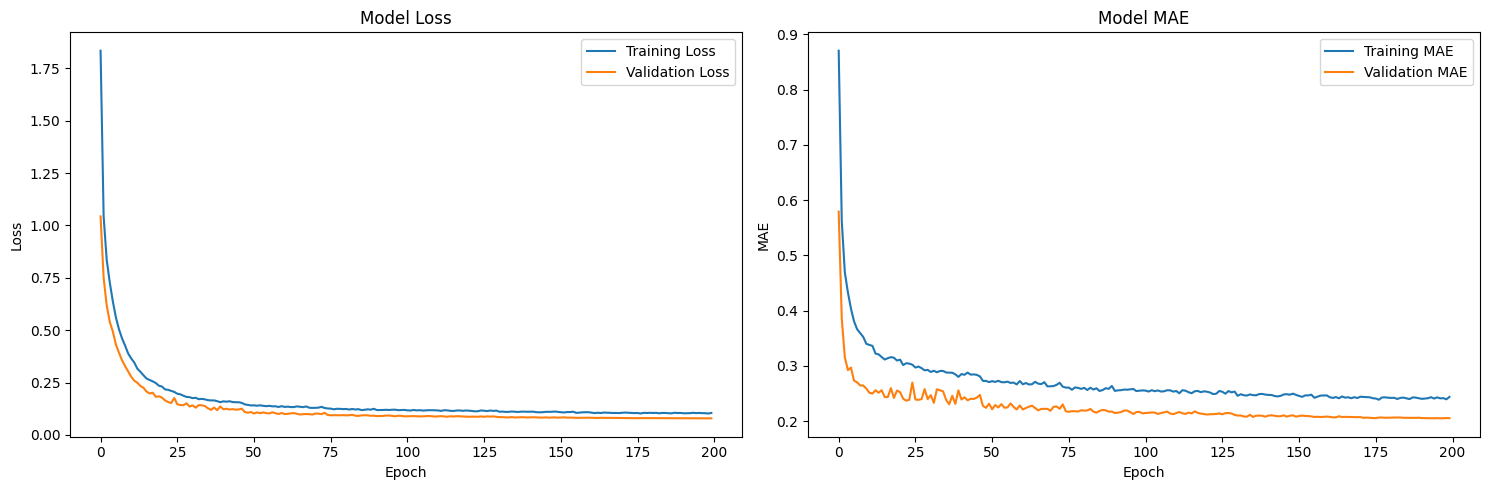

In [10]:
def run_temperature_humidity_forecasting(df):
    """Run dedicated temperature min forecasting"""
    print("🌡️ DEDICATED MINIMUM TEMPERATURE LSTM FORECASTING")
    print("=" * 70)
    
    # Initialize model
    model = TemperatureMinLSTM(df, sequence_length=10, forecast_horizon=3)
    
    # Preprocess data
    model.preprocess_data()
    
    # Train model
    results, history, y_true, y_pred = model.train_model(
        validation_split=0.2, 
        epochs=200, 
        batch_size=64
    )
    
    # Plot training history
    model.plot_training_history(history)
    
    return model, results, history, y_true, y_pred

# Usage example:
model, results, history, y_true, y_pred = run_temperature_humidity_forecasting(df)


🔮 Making 3-day Minimum temperature forecast...
--------------------------------------------------
📅 3-Day Minimum Temperature Forecast:
  Thursday   (2025-05-01):
     🌡️ temperature_2m_min (°C): 20.82
  Friday     (2025-05-02):
     🌡️ temperature_2m_min (°C): 20.82
  Saturday   (2025-05-03):
     🌡️ temperature_2m_min (°C): 20.81


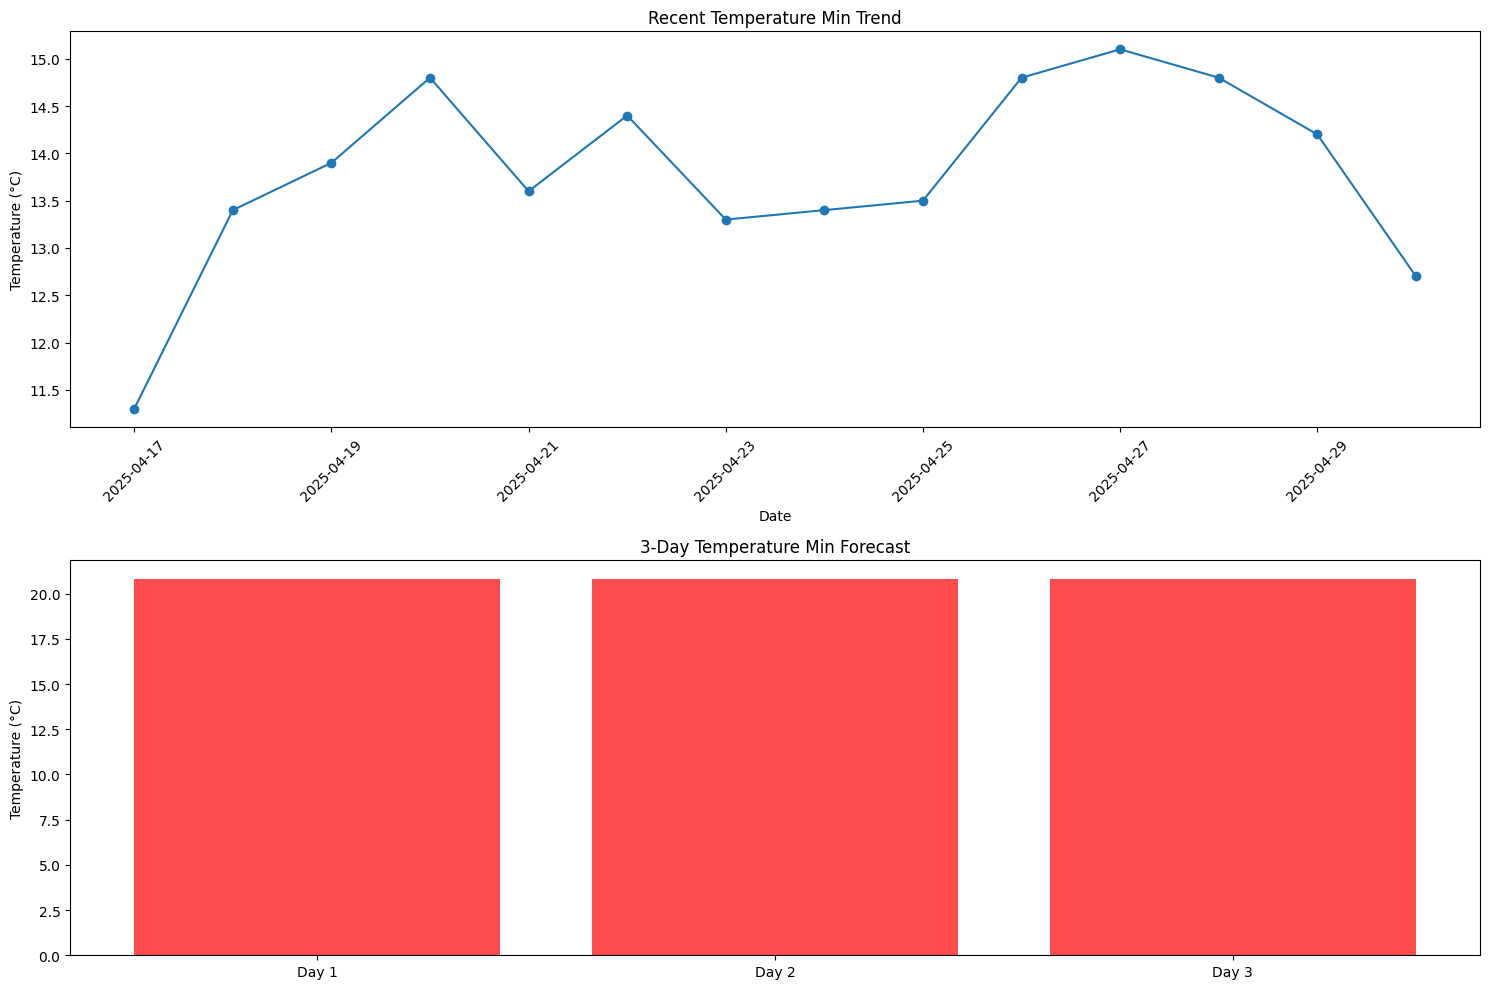

In [11]:
def make_predictions_and_visualize(model, df):
    """Make predictions and create visualizations for min temperature only"""
    import matplotlib.pyplot as plt
    from datetime import timedelta
    import pandas as pd
    import numpy as np
    
    print("\n🔮 Making 3-day Minimum temperature forecast...")
    print("-" * 50)
    
    # Get only the features used during training
    feature_cols = model.feature_cols

    # Pull only the last `sequence_length` rows
    recent_data = df[feature_cols].tail(model.sequence_length).copy()

    # Ensure numeric and same dtype
    recent_data = recent_data.apply(pd.to_numeric, errors='coerce').dropna()

    # If any rows dropped, re-pad from the top
    if len(recent_data) < model.sequence_length:
        padding_needed = model.sequence_length - len(recent_data)
        padding = np.zeros((padding_needed, len(feature_cols)))
        recent_data = np.vstack([padding, recent_data.values])
    else:
        recent_data = recent_data.values

    # Final shape must be (1, sequence_length, num_features)
    recent_data = recent_data.reshape(1, model.sequence_length, len(feature_cols)).astype(np.float32)

    try:
        # Get temperature/humidity predictions
        temp_humidity_results = model.predict_future(recent_data)
        
        # Get next 3 days
        last_date = pd.to_datetime(df['date']).max()
        next_3_dates = [last_date + timedelta(days=i+1) for i in range(3)]
        days_and_dates = [(d.strftime('%A'), d.strftime('%Y-%m-%d')) for d in next_3_dates]
        
        print("📅 3-Day Minimum Temperature Forecast:")
        for i, (day, date) in enumerate(days_and_dates):
            print(f"  {day:10} ({date}):")
            for target_name in model.available_targets:
                value = temp_humidity_results[target_name][i]
                print(f"     🌡️ {target_name}: {value:.2f}")
        
        # Visualization
        fig, axes = plt.subplots(2, 1, figsize=(15, 10))
        
        # Plot recent temperature trends
        if 'temperature_2m_min (°C)' in df.columns:
            recent_temp = df[['date', 'temperature_2m_min (°C)']].tail(14)
            recent_temp['date'] = pd.to_datetime(recent_temp['date'])
            axes[0].plot(recent_temp['date'], recent_temp['temperature_2m_min (°C)'], 'o-')
            axes[0].set_title('Recent Temperature Min Trend')
            axes[0].set_xlabel('Date')
            axes[0].set_ylabel('Temperature (°C)')
            axes[0].tick_params(axis='x', rotation=45)
        
        # Plot forecast temperature
        forecast_days = [f"Day {i+1}" for i in range(3)]
        if 'temperature_2m_min (°C)' in temp_humidity_results:
            temp_forecast = temp_humidity_results['temperature_2m_min (°C)']
            axes[1].bar(forecast_days, temp_forecast, color='red', alpha=0.7)
            axes[1].set_title('3-Day Temperature Min Forecast')
            axes[1].set_ylabel('Temperature (°C)')
        
        plt.tight_layout()
        plt.show()
        
        return temp_humidity_results
        
    except Exception as e:
        print(f"❌ Prediction error: {e}")
        return None


# Usage example:

predictions = make_predictions_and_visualize(model, df)

🌡️ MINIMUM TEMPERATURE PREDICTIONS

📅 Test Sequence 1:
------------------------------------------------------------

🌡️  temperature_2m_min (°C):
----------------------------------------
  Day |     Actual |  Predicted |      Error |    % Error
------------------------------------------------------------
    1 |      21.90 |      23.05 |       1.15 |       5.3%
    2 |      23.90 |      23.00 |       0.90 |       3.8%
    3 |      24.90 |      22.97 |       1.93 |       7.8%
------------------------------------------------------------
Sequence MAE: 1.329

📅 Test Sequence 2:
------------------------------------------------------------

🌡️  temperature_2m_min (°C):
----------------------------------------
  Day |     Actual |  Predicted |      Error |    % Error
------------------------------------------------------------
    1 |      20.40 |      21.05 |       0.65 |       3.2%
    2 |      20.70 |      21.05 |       0.35 |       1.7%
    3 |      22.90 |      21.04 |       1.86 |      

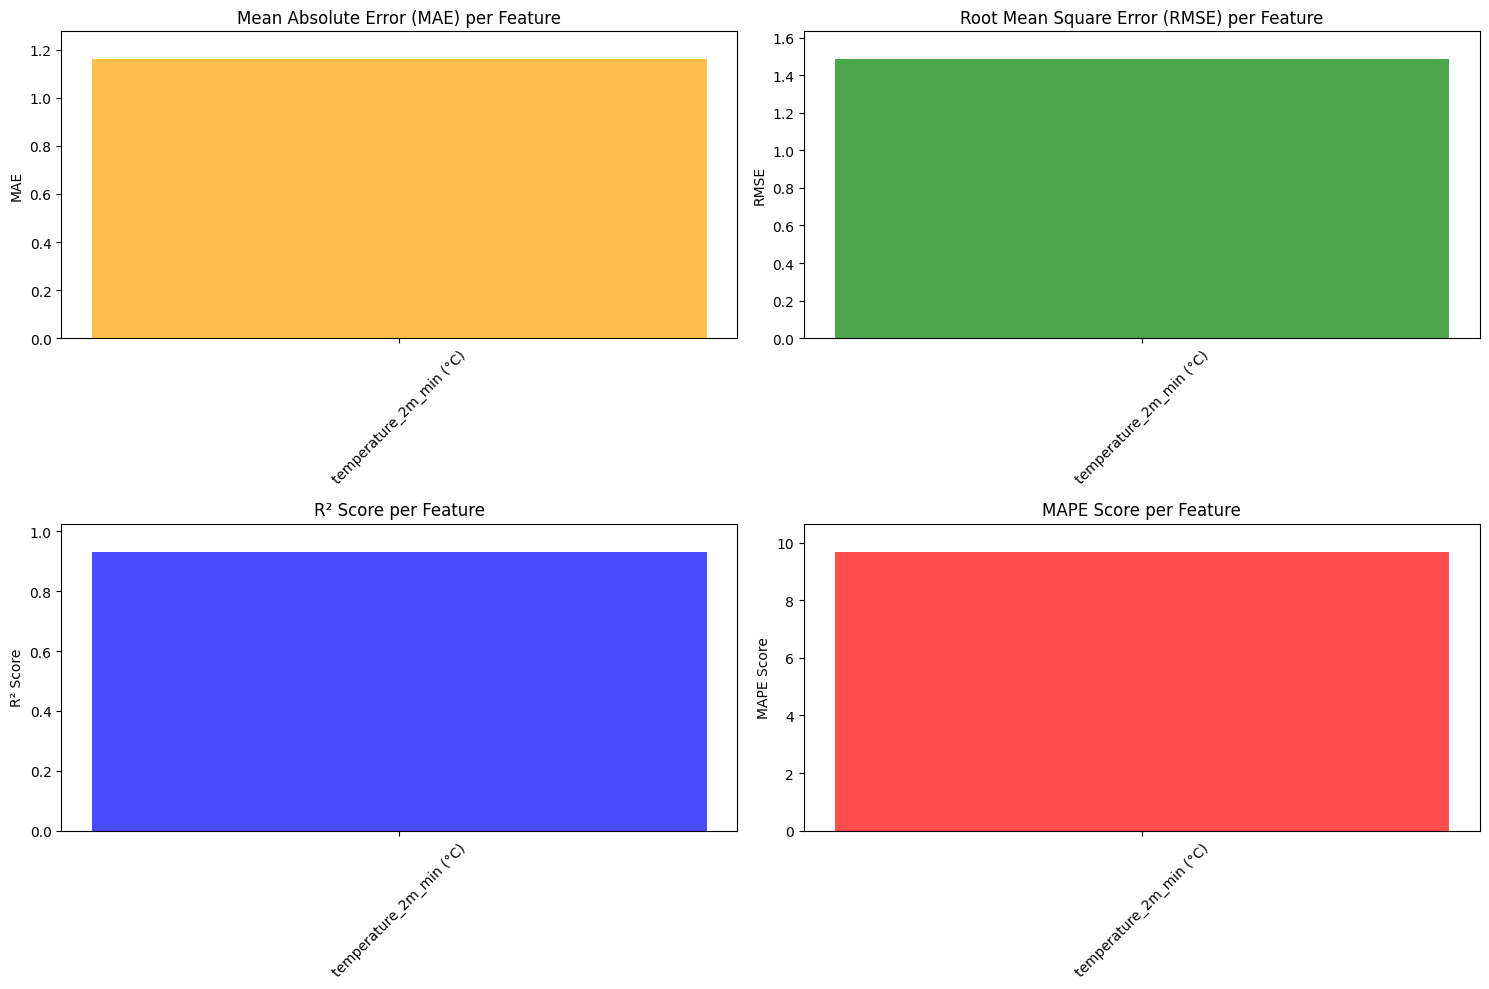


🏆 PERFORMANCE SUMMARY:
Best performing feature: temperature_2m_min (°C) (MAE: 1.160)
Worst performing feature: temperature_2m_min (°C) (MAE: 1.160)
Overall average MAE: 1.160
Overall average RMSE: 1.485
Overall average R²: 0.932


In [13]:
def show_regression_predictions(
    model, 
    y_true, 
    y_pred, 
    num_samples=5
):
    """Display temperature min regression predictions only."""
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    print("🌡️ MINIMUM TEMPERATURE PREDICTIONS")
    print("=" * 60)

    sample_size = min(num_samples, len(y_true))

    # Get feature names from the model
    feature_names = model.available_targets if hasattr(model, 'available_targets') else [f"Feature {i}" for i in range(y_true.shape[2])]

    # Display sample predictions
    for i in range(sample_size):
        print(f"\n📅 Test Sequence {i+1}:")
        print("-" * 60)

        # Create a nice table format for each feature
        for f, feature_name in enumerate(feature_names):
            print(f"\n🌡️  {feature_name}:")
            print("-" * 40)
            print(f"{'Day':>5} | {'Actual':>10} | {'Predicted':>10} | {'Error':>10} | {'% Error':>10}")
            print("-" * 60)

            mae_sequence = 0
            for day in range(model.forecast_horizon):
                actual = y_true[i, day, f]
                predicted = y_pred[i, day, f]
                error = abs(actual - predicted)
                percent_error = (error / (abs(actual) + 1e-8)) * 100
                mae_sequence += error

                print(f"{day+1:>5} | {actual:>10.2f} | {predicted:>10.2f} | {error:>10.2f} | {percent_error:>9.1f}%")

            mae_sequence /= model.forecast_horizon
            print("-" * 60)
            print(f"Sequence MAE: {mae_sequence:.3f}")

    # Overall statistics for temperature and humidity
    print(f"\n📊 OVERALL REGRESSION STATISTICS:")
    print("=" * 50)

    num_features = y_true.shape[2]

    for f, feature_name in enumerate(feature_names):
        print(f"\n🌡️  {feature_name}:")
        print("-" * 30)
        
        # Calculate metrics for this feature
        y_true_flat = y_true[:, :, f].flatten()
        y_pred_flat = y_pred[:, :, f].flatten()
        
        mae = mean_absolute_error(y_true_flat, y_pred_flat)
        rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
        r2 = r2_score(y_true_flat, y_pred_flat)
        mape = np.mean(np.abs((y_true_flat - y_pred_flat) / (y_true_flat + 1e-8))) * 100
        
        print(f"  MAE:  {mae:.3f}")
        print(f"  RMSE: {rmse:.3f}")
        print(f"  R²:   {r2:.3f}")
        print(f"  MAPE: {mape:.2f}%")
        
        # Per-day accuracy for this feature
        print(f"\n  📈 Daily Performance:")
        for day in range(model.forecast_horizon):
            day_true = y_true[:, day, f]
            day_pred = y_pred[:, day, f]
            day_mae = mean_absolute_error(day_true, day_pred)
            day_rmse = np.sqrt(mean_squared_error(day_true, day_pred))
            day_r2 = r2_score(day_true, day_pred)
            print(f"    Day {day+1}: MAE={day_mae:.3f}, RMSE={day_rmse:.3f}, R²={day_r2:.3f}")

    # Create visualization
    print(f"\n📈 CREATING PERFORMANCE VISUALIZATION...")
    
    # Calculate metrics for plotting
    maes = []
    rmses = []
    r2s = []
    mape = []
    
    for f in range(num_features):
        y_true_flat = y_true[:, :, f].flatten()
        y_pred_flat = y_pred[:, :, f].flatten()
        
        maes.append(mean_absolute_error(y_true_flat, y_pred_flat))
        rmses.append(np.sqrt(mean_squared_error(y_true_flat, y_pred_flat)))
        r2s.append(r2_score(y_true_flat, y_pred_flat))
        mape.append(np.mean(np.abs((y_true_flat - y_pred_flat) / (y_true_flat + 1e-8))) * 100)

    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # MAE plot
    axes[0, 0].bar(feature_names, maes, color='orange', alpha=0.7)
    axes[0, 0].set_title("Mean Absolute Error (MAE) per Feature")
    axes[0, 0].set_ylabel("MAE")
    axes[0, 0].set_ylim(0, max(maes) * 1.1)
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # RMSE plot
    axes[0, 1].bar(feature_names, rmses, color='green', alpha=0.7)
    axes[0, 1].set_title("Root Mean Square Error (RMSE) per Feature")
    axes[0, 1].set_ylabel("RMSE")
    axes[0, 1].set_ylim(0, max(rmses) * 1.1)
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # R² plot
    axes[1, 0].bar(feature_names, r2s, color='blue', alpha=0.7)
    axes[1, 0].set_title("R² Score per Feature")
    axes[1, 0].set_ylabel("R² Score")
    axes[1, 0].set_ylim(0, max(1.0, max(r2s) * 1.1))
    axes[1, 0].tick_params(axis='x', rotation=45)
    

    axes[1, 1].bar(feature_names, mape, color='red', alpha=0.7)
    axes[1, 1].set_title("MAPE Score per Feature")
    axes[1, 1].set_ylabel("MAPE Score")
    axes[1, 1].set_ylim(0, max(mape) * 1.1)
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    
    plt.tight_layout()
    plt.show()

    # Summary statistics
    print(f"\n🏆 PERFORMANCE SUMMARY:")
    print("=" * 30)
    print(f"Best performing feature: {feature_names[np.argmin(maes)]} (MAE: {min(maes):.3f})")
    print(f"Worst performing feature: {feature_names[np.argmax(maes)]} (MAE: {max(maes):.3f})")
    print(f"Overall average MAE: {np.mean(maes):.3f}")
    print(f"Overall average RMSE: {np.mean(rmses):.3f}")
    print(f"Overall average R²: {np.mean(r2s):.3f}")


# Usage example - replace your original function call with this:
show_regression_predictions(
    model, 
    y_true, 
    y_pred, 
    num_samples=3
)

In [14]:
def save_lstm_model(model, model_name="TemperatureMinLSTM", save_dir="saved_models"):
    import os
    import json
    import pickle
    from datetime import datetime
    import joblib

    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_folder = f"{save_dir}/{model_name.replace(' ', '_')}_{timestamp}"
    os.makedirs(model_folder, exist_ok=True)

    print(f"💾 Saving '{model_name}' to: {model_folder}")
    print("=" * 60)

    try:
        # 1. Save the Keras model
        model_path = f"{model_folder}/keras_model.keras"
        model.model.save(model_path)
        print("✅ Keras model saved.")

        # 2. Save scalers
        joblib.dump(model.scaler_features, f"{model_folder}/scaler_features.pkl")
        joblib.dump(model.scaler_targets, f"{model_folder}/scaler_targets.pkl")
        print("✅ Scalers saved.")

        # 3. Save config
        config = {
            'model_name': model_name,
            'sequence_length': model.sequence_length,
            'forecast_horizon': model.forecast_horizon,
            'available_targets': model.available_targets,
            'feature_columns': model.feature_cols,
            'timestamp': timestamp,
            'model_type': 'TemperatureMinLSTM',
            'framework': 'TensorFlow/Keras'
        }
        with open(f"{model_folder}/model_config.json", 'w') as f:
            json.dump(config, f, indent=4)
        print("✅ Model configuration saved.")

        # 4. Save model object (without keras model to avoid issues)
        model_copy = model.__dict__.copy()
        model_copy.pop('model', None)
        with open(f"{model_folder}/full_model.pkl", 'wb') as f:
            pickle.dump(model_copy, f)
        print("✅ Full model object saved.")

        return model_folder

    except Exception as e:
        print(f"❌ Error saving model: {e}")
        return None



def load_lstm_model(model_folder):
    import os
    import json
    import pickle
    import joblib
    from tensorflow.keras.models import load_model

    try:
        print(f"📂 Loading model from: {model_folder}")

        # Load keras model
        keras_model = load_model(f"{model_folder}/keras_model.keras")

        # Load scalers
        scaler_features = joblib.load(f"{model_folder}/scaler_features.pkl")
        scaler_targets = joblib.load(f"{model_folder}/scaler_targets.pkl")

        # Load config
        with open(f"{model_folder}/model_config.json", 'r') as f:
            config = json.load(f)

        # Load full model dict
        with open(f"{model_folder}/full_model.pkl", 'rb') as f:
            model_dict = pickle.load(f)

        # Create empty model object
        model = TemperatureMinLSTM(pd.DataFrame(), config['sequence_length'], config['forecast_horizon'])
        model.model = keras_model
        model.scaler_features = scaler_features
        model.scaler_targets = scaler_targets

        # Restore other attributes
        for key, value in model_dict.items():
            setattr(model, key, value)

        print(f"✅ Model '{config['model_name']}' successfully loaded!")
        return model

    except Exception as e:
        print(f"❌ Error loading model: {e}")
        return None


model_folder = save_lstm_model(model, model_name="MinimumTemperatureLSTM_Model1")

💾 Saving 'MinimumTemperatureLSTM_Model1' to: saved_models/MinimumTemperatureLSTM_Model1_20250706_161714
✅ Keras model saved.
✅ Scalers saved.
✅ Model configuration saved.
✅ Full model object saved.


3- Predicting the max humidity

In [3]:
class HumidityMaxLSTM:
    def __init__(self, df, sequence_length=10, forecast_horizon=3):
        """
        Dedicated LSTM model for humidity max prediction
        """
        self.df = df.copy()
        self.sequence_length = sequence_length
        self.forecast_horizon = forecast_horizon
        self.scaler_features = None
        self.scaler_targets = None
        self.model = None
        
        # Temperature and humidity target columns
        self.target_cols = [ 
            'relative_humidity_2m_max (%)'
        ]
        
    def preprocess_data(self):
        """Preprocess data specifically for max humidity prediction"""
        print("🧹 Preprocessing data for max humidity prediction...")
        df = self.df.copy()
        
        # Check which target columns are available
        available_targets = [col for col in self.target_cols if col in df.columns]
        if not available_targets:
            raise ValueError(f"None of the target columns {self.target_cols} found in the dataframe")
        
        self.available_targets = available_targets
        print(f"Available target columns: {available_targets}")
        
        # Handle missing values for targets
        for col in available_targets:
            df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
            df[col] = df[col].interpolate(method='linear')
            df[col].fillna(df[col].median(), inplace=True)
        
        # Remove rows with any missing target values
        df = df.dropna(subset=available_targets)
        
        # Define feature columns (exclude date, weather_condition, and target columns)
        exclude_cols = ['date', 'weather_condition','relative_humidity_2m_min (%)','temperature_2m_min (°C)', 'temperature_2m_max (°C)'] + available_targets
        feature_cols = [col for col in df.columns if col not in exclude_cols]
        
        # Handle missing values for features
        numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
            df[col] = df[col].interpolate(method='linear')
            df[col].fillna(df[col].median(), inplace=True)
        
        # Scale features
        self.scaler_features = StandardScaler()
        df[feature_cols] = self.scaler_features.fit_transform(df[feature_cols])
        
        # Scale targets
        self.scaler_targets = StandardScaler()
        df[available_targets] = self.scaler_targets.fit_transform(df[available_targets])
        
        # Store processed data
        self.df_processed = df
        self.feature_cols = feature_cols
        
        print(f"Feature columns ({len(feature_cols)}): {feature_cols[:5]}..." if len(feature_cols) > 5 else f"Feature columns: {feature_cols}")
        print(f"Target columns: {available_targets}")
        print(f"Data shape after preprocessing: {df.shape}")
        
        return df
    
    def create_sequences(self):
        """Create sequences for Maximum humidity prediction"""
        print(f"🪟 Creating sequences for Maximum humidity prediction...")
        
        X, y = [], []
        data = self.df_processed
        features = data[self.feature_cols].values
        targets = data[self.available_targets].values
        
        # Create sequences with sliding window
        for i in range(len(data) - self.sequence_length - self.forecast_horizon + 1):
            # Input sequence
            X_seq = features[i:i + self.sequence_length]
            
            # Target sequence (next forecast_horizon days)
            y_seq = targets[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            X.append(X_seq)
            y.append(y_seq)
        
        X = np.array(X)
        y = np.array(y)
        
        print(f"Created sequences: X={X.shape}, y={y.shape}")
        print(f"Input sequence length: {self.sequence_length}")
        print(f"Forecast horizon: {self.forecast_horizon}")
        print(f"Number of features: {X.shape[2]}")
        print(f"Number of target variables: {y.shape[2]}")
        
        return X, y
    
    def build_model(self, input_shape, output_shape):
        """Build LSTM model for Maximum humidity prediction"""
        model = Sequential([
            # First LSTM layer
            LSTM(128, return_sequences=True, input_shape=input_shape,
                 kernel_regularizer=l2(0.001), dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            
            # Second LSTM layer
            LSTM(64, return_sequences=True,
                 kernel_regularizer=l2(0.001), dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            
            # Third LSTM layer
            LSTM(32, return_sequences=False,
                 kernel_regularizer=l2(0.001), dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            Dropout(0.3),
            
            # Dense layers for multi-step prediction
            Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.3),
            
            Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
            Dropout(0.2),
            
            # Output layer - predict all forecast steps and variables at once
            Dense(output_shape[0] * output_shape[1], activation='linear'),
            
            # Reshape to (forecast_horizon, num_target_variables)
            tf.keras.layers.Reshape(output_shape)
        ])
        
        return model
    
    def train_model(self, validation_split=0.2, epochs=150, batch_size=32):
        """Train the Humidity max LSTM model"""
        print("\n" + "="*70)
        print("TRAINING HUMIDITY MAX LSTM MODEL")
        print("="*70)
        
        # Create sequences
        X, y = self.create_sequences()
        
        if len(X) == 0:
            raise ValueError("No sequences created!")
        
        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, shuffle=True
        )
        
        print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
        
        # Build model
        input_shape = (self.sequence_length, X.shape[2])
        output_shape = (self.forecast_horizon, len(self.available_targets))
        
        self.model = self.build_model(input_shape, output_shape)
        
        # Compile model
        self.model.compile(
            optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
            loss='mse',
            metrics=['mae']
        )
        
        print(f"\nModel architecture:")
        self.model.summary()
        
        # Callbacks
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7, verbose=1)
        ]
        
        # Train model
        print(f"\nTraining model...")
        history = self.model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=validation_split,
            callbacks=callbacks,
            verbose=1
        )
        
        # Evaluate
        print(f"\nEvaluating model...")
        y_pred = self.model.predict(X_test, verbose=0)
        
        return self.evaluate_model(y_test, y_pred, history)
    
    def evaluate_model(self, y_true, y_pred, history):
        """Evaluate the humidity max model"""
        print("\n" + "="*70)
        print("HUMIDITY MAX LSTM RESULTS")
        print("="*70)
        
        # Inverse transform predictions and true values to original scale
        y_true_original = np.zeros_like(y_true)
        y_pred_original = np.zeros_like(y_pred)
        
        for day in range(self.forecast_horizon):
            y_true_original[:, day, :] = self.scaler_targets.inverse_transform(y_true[:, day, :])
            y_pred_original[:, day, :] = self.scaler_targets.inverse_transform(y_pred[:, day, :])
        
        # Calculate metrics for each target variable and forecast day
        results = {}
        
        for i, target_name in enumerate(self.available_targets):
            print(f"\n🌡️ {target_name}:")
            print("-" * 50)
            
            target_results = {
                'mae': [],
                'rmse': [],
                'r2': [],
                'mape': []
            }
            
            for day in range(self.forecast_horizon):
                y_true_day = y_true_original[:, day, i]
                y_pred_day = y_pred_original[:, day, i]
                
                mae = mean_absolute_error(y_true_day, y_pred_day)
                rmse = np.sqrt(mean_squared_error(y_true_day, y_pred_day))
                r2 = r2_score(y_true_day, y_pred_day)
                
                # Calculate MAPE (Mean Absolute Percentage Error)
                mape = np.mean(np.abs((y_true_day - y_pred_day) / (y_true_day + 1e-8))) * 100
                
                target_results['mae'].append(mae)
                target_results['rmse'].append(rmse)
                target_results['r2'].append(r2)
                target_results['mape'].append(mape)
                
                print(f"  Day {day+1}: MAE={mae:.3f}, RMSE={rmse:.3f}, R²={r2:.3f}, MAPE={mape:.2f}%")
            
            # Calculate averages
            avg_mae = np.mean(target_results['mae'])
            avg_rmse = np.mean(target_results['rmse'])
            avg_r2 = np.mean(target_results['r2'])
            avg_mape = np.mean(target_results['mape'])
            
            target_results['avg_mae'] = avg_mae
            target_results['avg_rmse'] = avg_rmse
            target_results['avg_r2'] = avg_r2
            target_results['avg_mape'] = avg_mape
            
            print(f"  Average: MAE={avg_mae:.3f}, RMSE={avg_rmse:.3f}, R²={avg_r2:.3f}, MAPE={avg_mape:.2f}%")
            
            results[target_name] = target_results
        
        # Overall performance summary
        print(f"\n📊 OVERALL PERFORMANCE SUMMARY:")
        print("="*50)
        
        all_maes = [results[target]['avg_mae'] for target in self.available_targets]
        all_rmses = [results[target]['avg_rmse'] for target in self.available_targets]
        all_r2s = [results[target]['avg_r2'] for target in self.available_targets]
        all_mapes = [results[target]['avg_mape'] for target in self.available_targets]
        
        print(f"Overall Average MAE: {np.mean(all_maes):.3f}")
        print(f"Overall Average RMSE: {np.mean(all_rmses):.3f}")
        print(f"Overall Average R²: {np.mean(all_r2s):.3f}")
        print(f"Overall Average MAPE: {np.mean(all_mapes):.2f}%")
        
        # Best and worst performing variables
        best_target = min(results.keys(), key=lambda x: results[x]['avg_mae'])
        worst_target = max(results.keys(), key=lambda x: results[x]['avg_mae'])
        
        print(f"\n🏆 Best performing variable: {best_target} (MAE: {results[best_target]['avg_mae']:.3f})")
        print(f"⚠️  Worst performing variable: {worst_target} (MAE: {results[worst_target]['avg_mae']:.3f})")
        
        return results, history, y_true_original, y_pred_original
    
    
    def predict_future(self, recent_data):
        if isinstance(recent_data, pd.DataFrame):
            recent_scaled = self.scaler_features.transform(recent_data[self.feature_cols])
        elif isinstance(recent_data, np.ndarray):
            if recent_data.shape[1] == len(self.feature_cols):
                recent_scaled = self.scaler_features.transform(recent_data)
            else:
                recent_scaled = recent_data
        else:
            raise ValueError("recent_data must be a DataFrame or NumPy array")

        input_seq = recent_scaled[-self.sequence_length:].reshape(1, self.sequence_length, -1)
        prediction_scaled = self.model.predict(input_seq, verbose=0)

        # Inverse transform
        prediction_original = np.zeros_like(prediction_scaled)
        for day in range(self.forecast_horizon):
            prediction_original[0, day, :] = self.scaler_targets.inverse_transform(
                prediction_scaled[0, day, :].reshape(1, -1)
            )

        predicted_values = prediction_original[0, :, 0]  # shape: (forecast_horizon,)

        return predicted_values
    
    def plot_training_history(self, history):
        """Plot training history"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Loss
        ax1.plot(history.history['loss'], label='Training Loss')
        ax1.plot(history.history['val_loss'], label='Validation Loss')
        ax1.set_title('Model Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()
        
        # MAE
        ax2.plot(history.history['mae'], label='Training MAE')
        ax2.plot(history.history['val_mae'], label='Validation MAE')
        ax2.set_title('Model MAE')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('MAE')
        ax2.legend()
        
        plt.tight_layout()
        plt.show()

🌡️ DEDICATED MAXIMUM HUMIDITY LSTM FORECASTING
🧹 Preprocessing data for max humidity prediction...
Available target columns: ['relative_humidity_2m_max (%)']
Feature columns (144): ['year', 'month', 'day', 'dayofweek', 'is_weekend']...
Target columns: ['relative_humidity_2m_max (%)']
Data shape after preprocessing: (9252, 150)

TRAINING HUMIDITY MAX LSTM MODEL
🪟 Creating sequences for Maximum humidity prediction...
Created sequences: X=(9240, 10, 144), y=(9240, 3, 1)
Input sequence length: 10
Forecast horizon: 3
Number of features: 144
Number of target variables: 1
Training samples: 7392, Test samples: 1848

Model architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 128)        │       139,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 3, 1)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 207,043 (808.76 KB)

 Trainable params: 206,467 (806.51 KB)

 Non-trainable params: 576 (2.25 KB)


Training model...
Epoch 1/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - loss: 3.1623 - mae: 1.2686 - val_loss: 1.5999 - val_mae: 0.7891 - learning_rate: 0.0010
Epoch 2/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 1.8956 - mae: 0.9123 - val_loss: 1.5649 - val_mae: 0.7835 - learning_rate: 0.0010
Epoch 3/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 1.6840 - mae: 0.8415 - val_loss: 1.5356 - val_mae: 0.7799 - learning_rate: 0.0010
Epoch 4/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 1.5771 - mae: 0.8203 - val_loss: 1.4644 - val_mae: 0.7824 - learning_rate: 0.0010
Epoch 5/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 1.4704 - mae: 0.7935 - val_loss: 1.4061 - val_mae: 0.7737 - learning_rate: 0.0010
Epoch 6/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 1.4272 - mae: 0.7956 - val_loss: 1.3605 - val_mae: 0.7661 - learning_rate: 0.0010
Epoch 7/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 1.3921 - mae: 0.7904 - val_loss: 1.3146 - val_mae: 0.7620 - learning

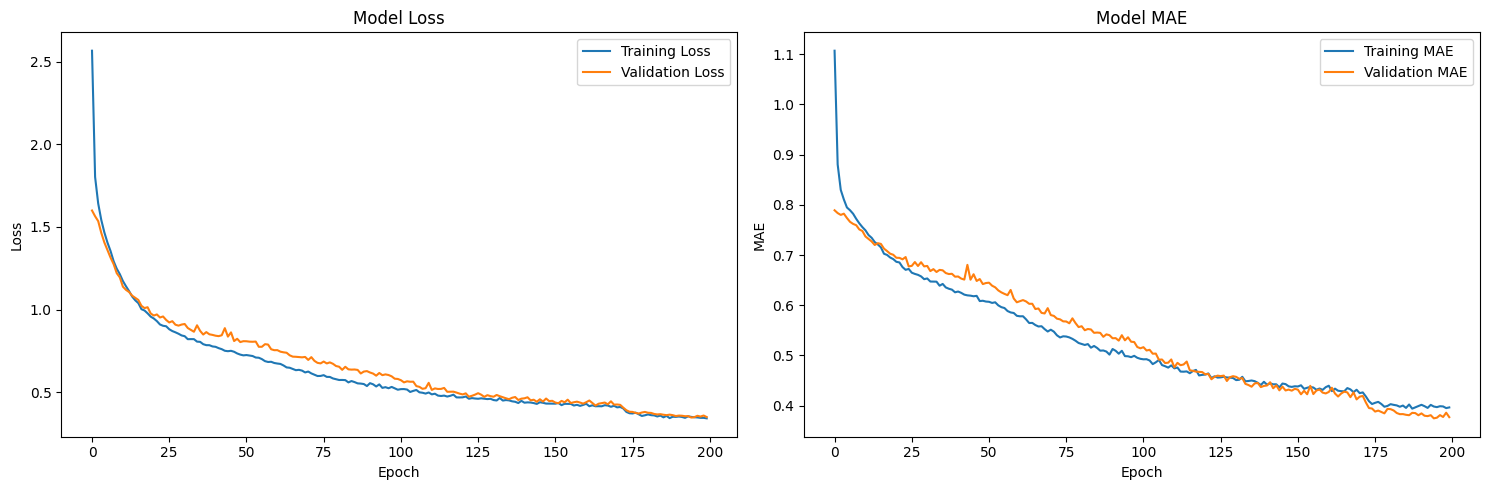

In [4]:
def run_temperature_humidity_forecasting(df):
    """Run dedicated humidity forecasting"""
    print("🌡️ DEDICATED MAXIMUM HUMIDITY LSTM FORECASTING")
    print("=" * 70)
    
    # Initialize model
    model = HumidityMaxLSTM(df, sequence_length=10, forecast_horizon=3)
    
    # Preprocess data
    model.preprocess_data()
    
    # Train model
    results, history, y_true, y_pred = model.train_model(
        validation_split=0.2, 
        epochs=200, 
        batch_size=64
    )
    
    # Plot training history
    model.plot_training_history(history)
    
    return model, results, history, y_true, y_pred

# Usage example:
model, results, history, y_true, y_pred = run_temperature_humidity_forecasting(df)




🔮 Making 3-day Maximum temperature forecast...
--------------------------------------------------
📅 3-Day Maximum Temperature Forecast:
  Thursday   (2025-05-01): 🌡️ 90.10 °C
  Friday     (2025-05-02): 🌡️ 87.63 °C
  Saturday   (2025-05-03): 🌡️ 88.78 °C


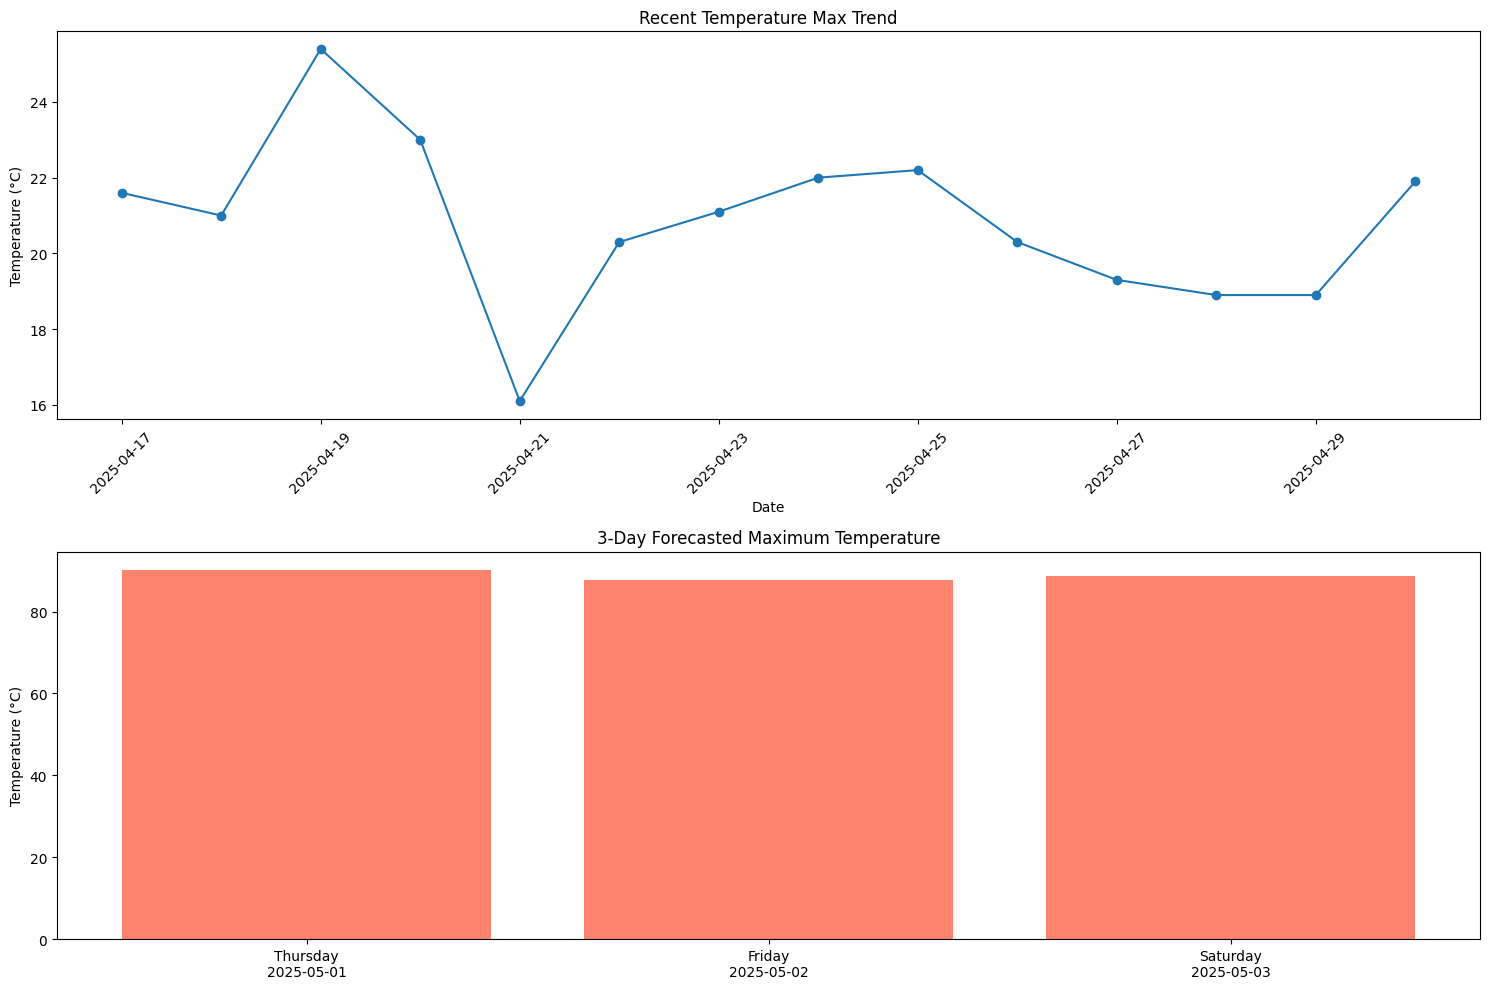

In [5]:
def make_predictions_and_visualize(model, df):
    """Make predictions and create visualizations for min temperature only"""
    import matplotlib.pyplot as plt
    from datetime import timedelta
    import pandas as pd
    import numpy as np
    
    print("\n🔮 Making 3-day Maximum temperature forecast...")
    print("-" * 50)
    
    # Get only the features used during training
    feature_cols = model.feature_cols

    # Pull only the last `sequence_length` rows
    recent_data = df[feature_cols].tail(model.sequence_length).copy()

    # Ensure numeric and same dtype
    recent_data = recent_data.apply(pd.to_numeric, errors='coerce').dropna()

    # If any rows dropped, re-pad from the top
    if len(recent_data) < model.sequence_length:
        padding_needed = model.sequence_length - len(recent_data)
        padding = np.zeros((padding_needed, len(feature_cols)))
        recent_data = np.vstack([padding, recent_data.values])
    else:
        recent_data = recent_data.values

    # Final shape must be (1, sequence_length, num_features)
    recent_data = recent_data.reshape(1, model.sequence_length, len(feature_cols)).astype(np.float32)

    try:
        # Get temperature/humidity predictions
        temp_results = model.predict_future(recent_data)
        
        # Get next 3 days
        last_date = pd.to_datetime(df['date']).max()
        next_3_dates = [last_date + timedelta(days=i+1) for i in range(3)]
        days_and_dates = [(d.strftime('%A'), d.strftime('%Y-%m-%d')) for d in next_3_dates]
        
        print("📅 3-Day Maximum Temperature Forecast:")
        for (day, date), temp_result in zip(days_and_dates, temp_results):
            print(f"  {day:10} ({date}): 🌡️ {temp_result:.2f} °C")
        
        
        # Visualization
        fig, axes = plt.subplots(2, 1, figsize=(15, 10))
        
        # Plot recent temperature trends
        if 'temperature_2m_max (°C)' in df.columns:
            recent_temp = df[['date', 'temperature_2m_max (°C)']].tail(14)
            recent_temp['date'] = pd.to_datetime(recent_temp['date'])
            axes[0].plot(recent_temp['date'], recent_temp['temperature_2m_max (°C)'], 'o-')
            axes[0].set_title('Recent Temperature Max Trend')
            axes[0].set_xlabel('Date')
            axes[0].set_ylabel('Temperature (°C)')
            axes[0].tick_params(axis='x', rotation=45)
        
        # Plot forecast temperature
        forecast_labels = [f"{day}\n{date}" for day, date in days_and_dates]
        axes[1].bar(forecast_labels, temp_results, color='tomato', alpha=0.8)
        axes[1].set_title('3-Day Forecasted Maximum Temperature')
        axes[1].set_ylabel('Temperature (°C)')
        
        plt.tight_layout()
        plt.show()
        
        return temp_results
        
    except Exception as e:
        print(f"❌ Prediction error: {e}")
        return None


# Usage example:

predictions = make_predictions_and_visualize(model, df)

🌡️ MAXIMUM HUMIDITY PREDICTIONS

📅 Test Sequence 1:
------------------------------------------------------------

🌡️  relative_humidity_2m_max (%):
----------------------------------------
  Day |     Actual |  Predicted |      Error |    % Error
------------------------------------------------------------
    1 |      98.00 |      92.78 |       5.22 |       5.3%
    2 |      90.00 |      85.93 |       4.07 |       4.5%
    3 |      87.00 |      88.41 |       1.41 |       1.6%
------------------------------------------------------------
Sequence MAE: 3.568

📅 Test Sequence 2:
------------------------------------------------------------

🌡️  relative_humidity_2m_max (%):
----------------------------------------
  Day |     Actual |  Predicted |      Error |    % Error
------------------------------------------------------------
    1 |      89.00 |      91.33 |       2.33 |       2.6%
    2 |      93.00 |      92.43 |       0.57 |       0.6%
    3 |      92.00 |      92.81 |       0.81 

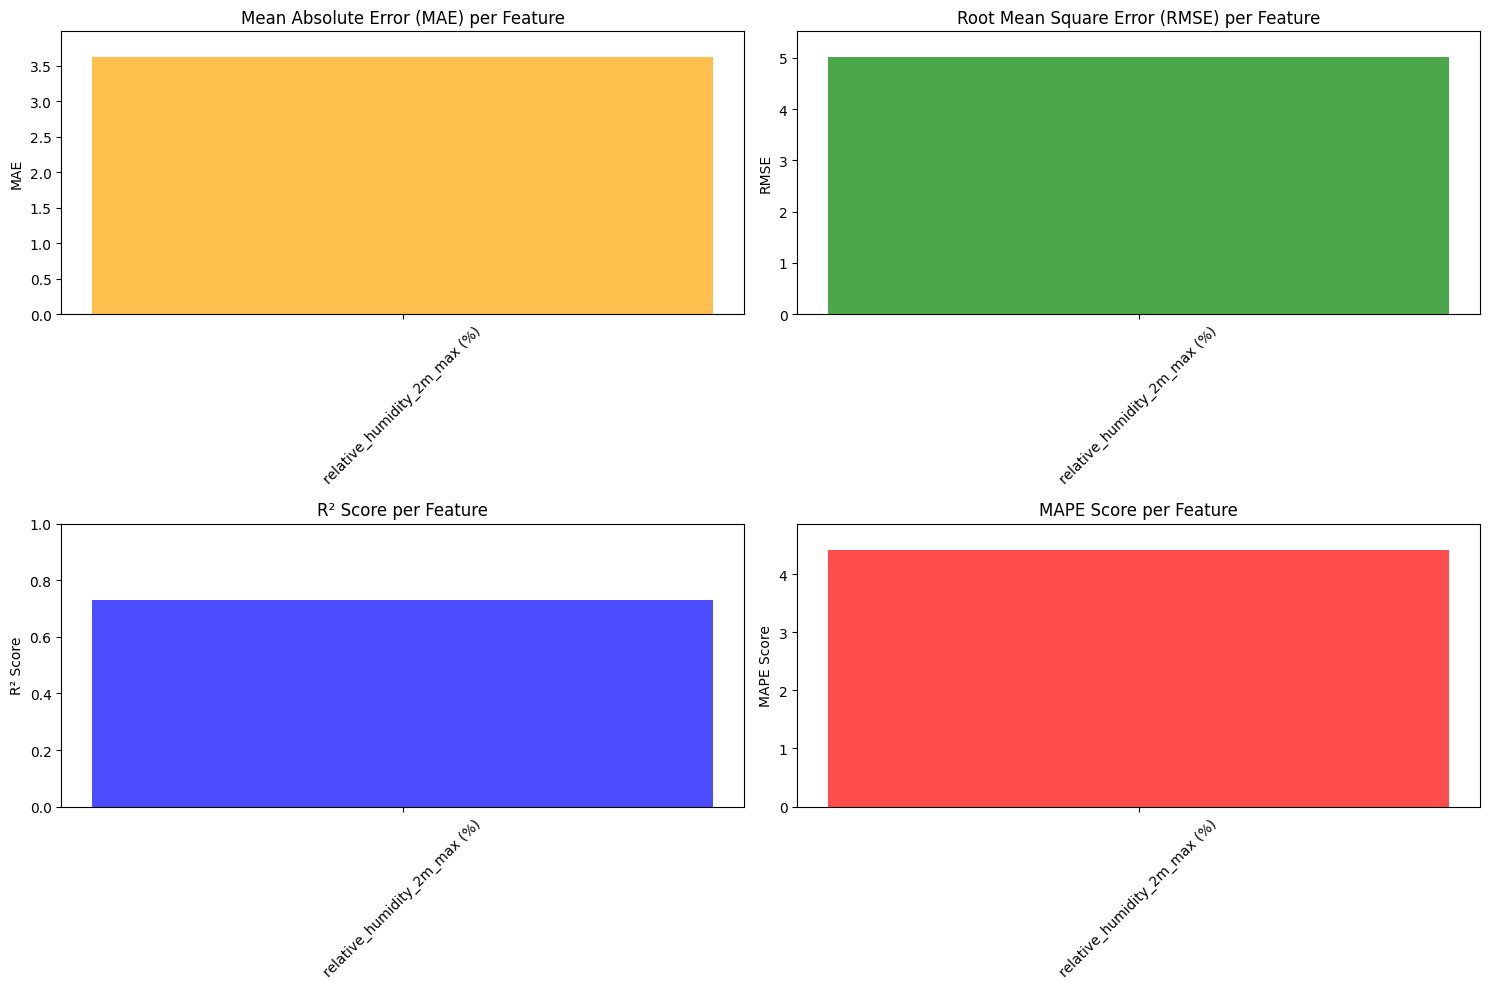


🏆 PERFORMANCE SUMMARY:
Best performing feature: relative_humidity_2m_max (%) (MAE: 3.621)
Worst performing feature: relative_humidity_2m_max (%) (MAE: 3.621)
Overall average MAE: 3.621
Overall average RMSE: 5.015
Overall average R²: 0.732


In [6]:
def show_regression_predictions(
    model, 
    y_true, 
    y_pred, 
    num_samples=5
):
    """Display humidity regression predictions only."""
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    print("🌡️ MAXIMUM HUMIDITY PREDICTIONS")
    print("=" * 60)

    sample_size = min(num_samples, len(y_true))

    # Get feature names from the model
    feature_names = model.available_targets if hasattr(model, 'available_targets') else [f"Feature {i}" for i in range(y_true.shape[2])]

    # Display sample predictions
    for i in range(sample_size):
        print(f"\n📅 Test Sequence {i+1}:")
        print("-" * 60)

        # Create a nice table format for each feature
        for f, feature_name in enumerate(feature_names):
            print(f"\n🌡️  {feature_name}:")
            print("-" * 40)
            print(f"{'Day':>5} | {'Actual':>10} | {'Predicted':>10} | {'Error':>10} | {'% Error':>10}")
            print("-" * 60)

            mae_sequence = 0
            for day in range(model.forecast_horizon):
                actual = y_true[i, day, f]
                predicted = y_pred[i, day, f]
                error = abs(actual - predicted)
                percent_error = (error / (abs(actual) + 1e-8)) * 100
                mae_sequence += error

                print(f"{day+1:>5} | {actual:>10.2f} | {predicted:>10.2f} | {error:>10.2f} | {percent_error:>9.1f}%")

            mae_sequence /= model.forecast_horizon
            print("-" * 60)
            print(f"Sequence MAE: {mae_sequence:.3f}")

    # Overall statistics for temperature and humidity
    print(f"\n📊 OVERALL REGRESSION STATISTICS:")
    print("=" * 50)

    num_features = y_true.shape[2]

    for f, feature_name in enumerate(feature_names):
        print(f"\n🌡️  {feature_name}:")
        print("-" * 30)
        
        # Calculate metrics for this feature
        y_true_flat = y_true[:, :, f].flatten()
        y_pred_flat = y_pred[:, :, f].flatten()
        
        mae = mean_absolute_error(y_true_flat, y_pred_flat)
        rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
        r2 = r2_score(y_true_flat, y_pred_flat)
        mape = np.mean(np.abs((y_true_flat - y_pred_flat) / (y_true_flat + 1e-8))) * 100
        
        print(f"  MAE:  {mae:.3f}")
        print(f"  RMSE: {rmse:.3f}")
        print(f"  R²:   {r2:.3f}")
        print(f"  MAPE: {mape:.2f}%")
        
        # Per-day accuracy for this feature
        print(f"\n  📈 Daily Performance:")
        for day in range(model.forecast_horizon):
            day_true = y_true[:, day, f]
            day_pred = y_pred[:, day, f]
            day_mae = mean_absolute_error(day_true, day_pred)
            day_rmse = np.sqrt(mean_squared_error(day_true, day_pred))
            day_r2 = r2_score(day_true, day_pred)
            print(f"    Day {day+1}: MAE={day_mae:.3f}, RMSE={day_rmse:.3f}, R²={day_r2:.3f}")

    # Create visualization
    print(f"\n📈 CREATING PERFORMANCE VISUALIZATION...")
    
    # Calculate metrics for plotting
    maes = []
    rmses = []
    r2s = []
    mape = []
    
    for f in range(num_features):
        y_true_flat = y_true[:, :, f].flatten()
        y_pred_flat = y_pred[:, :, f].flatten()
        
        maes.append(mean_absolute_error(y_true_flat, y_pred_flat))
        rmses.append(np.sqrt(mean_squared_error(y_true_flat, y_pred_flat)))
        r2s.append(r2_score(y_true_flat, y_pred_flat))
        mape.append(np.mean(np.abs((y_true_flat - y_pred_flat) / (y_true_flat + 1e-8))) * 100)

    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # MAE plot
    axes[0, 0].bar(feature_names, maes, color='orange', alpha=0.7)
    axes[0, 0].set_title("Mean Absolute Error (MAE) per Feature")
    axes[0, 0].set_ylabel("MAE")
    axes[0, 0].set_ylim(0, max(maes) * 1.1)
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # RMSE plot
    axes[0, 1].bar(feature_names, rmses, color='green', alpha=0.7)
    axes[0, 1].set_title("Root Mean Square Error (RMSE) per Feature")
    axes[0, 1].set_ylabel("RMSE")
    axes[0, 1].set_ylim(0, max(rmses) * 1.1)
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # R² plot
    axes[1, 0].bar(feature_names, r2s, color='blue', alpha=0.7)
    axes[1, 0].set_title("R² Score per Feature")
    axes[1, 0].set_ylabel("R² Score")
    axes[1, 0].set_ylim(0, max(1.0, max(r2s) * 1.1))
    axes[1, 0].tick_params(axis='x', rotation=45)
    

    axes[1, 1].bar(feature_names, mape, color='red', alpha=0.7)
    axes[1, 1].set_title("MAPE Score per Feature")
    axes[1, 1].set_ylabel("MAPE Score")
    axes[1, 1].set_ylim(0, max(mape) * 1.1)
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    
    plt.tight_layout()
    plt.show()

    # Summary statistics
    print(f"\n🏆 PERFORMANCE SUMMARY:")
    print("=" * 30)
    print(f"Best performing feature: {feature_names[np.argmin(maes)]} (MAE: {min(maes):.3f})")
    print(f"Worst performing feature: {feature_names[np.argmax(maes)]} (MAE: {max(maes):.3f})")
    print(f"Overall average MAE: {np.mean(maes):.3f}")
    print(f"Overall average RMSE: {np.mean(rmses):.3f}")
    print(f"Overall average R²: {np.mean(r2s):.3f}")


# Usage example - replace your original function call with this:
show_regression_predictions(
    model, 
    y_true, 
    y_pred, 
    num_samples=3
)

In [7]:
def save_lstm_model(model, model_name="HumidityMaxLSTM", save_dir="saved_models"):
    import os
    import json
    import pickle
    from datetime import datetime
    import joblib

    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_folder = f"{save_dir}/{model_name.replace(' ', '_')}_{timestamp}"
    os.makedirs(model_folder, exist_ok=True)

    print(f"💾 Saving '{model_name}' to: {model_folder}")
    print("=" * 60)

    try:
        # 1. Save the Keras model
        model_path = f"{model_folder}/keras_model.keras"
        model.model.save(model_path)
        print("✅ Keras model saved.")

        # 2. Save scalers
        joblib.dump(model.scaler_features, f"{model_folder}/scaler_features.pkl")
        joblib.dump(model.scaler_targets, f"{model_folder}/scaler_targets.pkl")
        print("✅ Scalers saved.")

        # 3. Save config
        config = {
            'model_name': model_name,
            'sequence_length': model.sequence_length,
            'forecast_horizon': model.forecast_horizon,
            'available_targets': model.available_targets,
            'feature_columns': model.feature_cols,
            'timestamp': timestamp,
            'model_type': 'HumidityMaxLSTM',
            'framework': 'TensorFlow/Keras'
        }
        with open(f"{model_folder}/model_config.json", 'w') as f:
            json.dump(config, f, indent=4)
        print("✅ Model configuration saved.")

        # 4. Save model object (without keras model to avoid issues)
        model_copy = model.__dict__.copy()
        model_copy.pop('model', None)
        with open(f"{model_folder}/full_model.pkl", 'wb') as f:
            pickle.dump(model_copy, f)
        print("✅ Full model object saved.")

        return model_folder

    except Exception as e:
        print(f"❌ Error saving model: {e}")
        return None



def load_lstm_model(model_folder):
    import os
    import json
    import pickle
    import joblib
    from tensorflow.keras.models import load_model

    try:
        print(f"📂 Loading model from: {model_folder}")

        # Load keras model
        keras_model = load_model(f"{model_folder}/keras_model.keras")

        # Load scalers
        scaler_features = joblib.load(f"{model_folder}/scaler_features.pkl")
        scaler_targets = joblib.load(f"{model_folder}/scaler_targets.pkl")

        # Load config
        with open(f"{model_folder}/model_config.json", 'r') as f:
            config = json.load(f)

        # Load full model dict
        with open(f"{model_folder}/full_model.pkl", 'rb') as f:
            model_dict = pickle.load(f)

        # Create empty model object
        model = HumidityMaxLSTM(pd.DataFrame(), config['sequence_length'], config['forecast_horizon'])
        model.model = keras_model
        model.scaler_features = scaler_features
        model.scaler_targets = scaler_targets

        # Restore other attributes
        for key, value in model_dict.items():
            setattr(model, key, value)

        print(f"✅ Model '{config['model_name']}' successfully loaded!")
        return model

    except Exception as e:
        print(f"❌ Error loading model: {e}")
        return None


model_folder = save_lstm_model(model, model_name="MaximumHumidityLSTM_Model1")

💾 Saving 'MaximumHumidityLSTM_Model1' to: saved_models/MaximumHumidityLSTM_Model1_20250726_221759
✅ Keras model saved.
✅ Scalers saved.
✅ Model configuration saved.
✅ Full model object saved.


4- Predicting the min humidity

In [ ]:
class HumidityMinLSTM:
    def __init__(self, df, sequence_length=10, forecast_horizon=3):
        """
        Dedicated LSTM model for min umidity prediction
        """
        self.df = df.copy()
        self.sequence_length = sequence_length
        self.forecast_horizon = forecast_horizon
        self.scaler_features = None
        self.scaler_targets = None
        self.model = None
        
        # Temperature and humidity target columns
        self.target_cols = [
            'relative_humidity_2m_min (%)'
        ]
        
    def preprocess_data(self):
        """Preprocess data specifically for humidity prediction"""
        print("🧹 Preprocessing data for humidity prediction...")
        df = self.df.copy()
        
        # Check which target columns are available
        available_targets = [col for col in self.target_cols if col in df.columns]
        if not available_targets:
            raise ValueError(f"None of the target columns {self.target_cols} found in the dataframe")
        
        self.available_targets = available_targets
        print(f"Available target columns: {available_targets}")
        
        # Handle missing values for targets
        for col in available_targets:
            df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
            df[col] = df[col].interpolate(method='linear')
            df[col].fillna(df[col].median(), inplace=True)
        
        # Remove rows with any missing target values
        df = df.dropna(subset=available_targets)
        
        # Define feature columns (exclude date, weather_condition, and target columns)
        exclude_cols = ['date', 'weather_condition'] + available_targets
        feature_cols = [col for col in df.columns if col not in exclude_cols]
        
        # Handle missing values for features
        numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
            df[col] = df[col].interpolate(method='linear')
            df[col].fillna(df[col].median(), inplace=True)
        
        # Scale features
        self.scaler_features = StandardScaler()
        df[feature_cols] = self.scaler_features.fit_transform(df[feature_cols])
        
        # Scale targets
        self.scaler_targets = StandardScaler()
        df[available_targets] = self.scaler_targets.fit_transform(df[available_targets])
        
        # Store processed data
        self.df_processed = df
        self.feature_cols = feature_cols
        
        print(f"Feature columns ({len(feature_cols)}): {feature_cols[:5]}..." if len(feature_cols) > 5 else f"Feature columns: {feature_cols}")
        print(f"Target columns: {available_targets}")
        print(f"Data shape after preprocessing: {df.shape}")
        
        return df
    
    def create_sequences(self):
        """Create sequences for Minimum humidity prediction"""
        print(f"🪟 Creating sequences for Minimum humidity prediction...")
        
        X, y = [], []
        data = self.df_processed
        features = data[self.feature_cols].values
        targets = data[self.available_targets].values
        
        # Create sequences with sliding window
        for i in range(len(data) - self.sequence_length - self.forecast_horizon + 1):
            # Input sequence
            X_seq = features[i:i + self.sequence_length]
            
            # Target sequence (next forecast_horizon days)
            y_seq = targets[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            X.append(X_seq)
            y.append(y_seq)
        
        X = np.array(X)
        y = np.array(y)
        
        print(f"Created sequences: X={X.shape}, y={y.shape}")
        print(f"Input sequence length: {self.sequence_length}")
        print(f"Forecast horizon: {self.forecast_horizon}")
        print(f"Number of features: {X.shape[2]}")
        print(f"Number of target variables: {y.shape[2]}")
        
        return X, y
    
    def build_model(self, input_shape, output_shape):
        """Build LSTM model for Minimum humidity prediction"""
        model = Sequential([
            # First LSTM layer
            LSTM(128, return_sequences=True, input_shape=input_shape,
                 kernel_regularizer=l2(0.001), dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            
            # Second LSTM layer
            LSTM(64, return_sequences=True,
                 kernel_regularizer=l2(0.001), dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            
            # Third LSTM layer
            LSTM(32, return_sequences=False,
                 kernel_regularizer=l2(0.001), dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            Dropout(0.3),
            
            # Dense layers for multi-step prediction
            Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.3),
            
            Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
            Dropout(0.2),
            
            # Output layer - predict all forecast steps and variables at once
            Dense(output_shape[0] * output_shape[1], activation='linear'),
            
            # Reshape to (forecast_horizon, num_target_variables)
            tf.keras.layers.Reshape(output_shape)
        ])
        
        return model
    
    def train_model(self, validation_split=0.2, epochs=150, batch_size=32):
        """Train the humidity min LSTM model"""
        print("\n" + "="*70)
        print("TRAINING HUMIDITY MIN LSTM MODEL")
        print("="*70)
        
        # Create sequences
        X, y = self.create_sequences()
        
        if len(X) == 0:
            raise ValueError("No sequences created!")
        
        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, shuffle=True
        )
        
        print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
        
        # Build model
        input_shape = (self.sequence_length, X.shape[2])
        output_shape = (self.forecast_horizon, len(self.available_targets))
        
        self.model = self.build_model(input_shape, output_shape)
        
        # Compile model
        self.model.compile(
            optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
            loss='mse',
            metrics=['mae']
        )
        
        print(f"\nModel architecture:")
        self.model.summary()
        
        # Callbacks
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7, verbose=1)
        ]
        
        # Train model
        print(f"\nTraining model...")
        history = self.model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=validation_split,
            callbacks=callbacks,
            verbose=1
        )
        
        # Evaluate
        print(f"\nEvaluating model...")
        y_pred = self.model.predict(X_test, verbose=0)
        
        return self.evaluate_model(y_test, y_pred, history)
    
    def evaluate_model(self, y_true, y_pred, history):
        """Evaluate the humidity model"""
        print("\n" + "="*70)
        print("HUMIDITY MIN LSTM RESULTS")
        print("="*70)
        
        # Inverse transform predictions and true values to original scale
        y_true_original = np.zeros_like(y_true)
        y_pred_original = np.zeros_like(y_pred)
        
        for day in range(self.forecast_horizon):
            y_true_original[:, day, :] = self.scaler_targets.inverse_transform(y_true[:, day, :])
            y_pred_original[:, day, :] = self.scaler_targets.inverse_transform(y_pred[:, day, :])
        
        # Calculate metrics for each target variable and forecast day
        results = {}
        
        for i, target_name in enumerate(self.available_targets):
            print(f"\n🌡️ {target_name}:")
            print("-" * 50)
            
            target_results = {
                'mae': [],
                'rmse': [],
                'r2': [],
                'mape': []
            }
            
            for day in range(self.forecast_horizon):
                y_true_day = y_true_original[:, day, i]
                y_pred_day = y_pred_original[:, day, i]
                
                mae = mean_absolute_error(y_true_day, y_pred_day)
                rmse = np.sqrt(mean_squared_error(y_true_day, y_pred_day))
                r2 = r2_score(y_true_day, y_pred_day)
                
                # Calculate MAPE (Mean Absolute Percentage Error)
                mape = np.mean(np.abs((y_true_day - y_pred_day) / (y_true_day + 1e-8))) * 100
                
                target_results['mae'].append(mae)
                target_results['rmse'].append(rmse)
                target_results['r2'].append(r2)
                target_results['mape'].append(mape)
                
                print(f"  Day {day+1}: MAE={mae:.3f}, RMSE={rmse:.3f}, R²={r2:.3f}, MAPE={mape:.2f}%")
            
            # Calculate averages
            avg_mae = np.mean(target_results['mae'])
            avg_rmse = np.mean(target_results['rmse'])
            avg_r2 = np.mean(target_results['r2'])
            avg_mape = np.mean(target_results['mape'])
            
            target_results['avg_mae'] = avg_mae
            target_results['avg_rmse'] = avg_rmse
            target_results['avg_r2'] = avg_r2
            target_results['avg_mape'] = avg_mape
            
            print(f"  Average: MAE={avg_mae:.3f}, RMSE={avg_rmse:.3f}, R²={avg_r2:.3f}, MAPE={avg_mape:.2f}%")
            
            results[target_name] = target_results
        
        # Overall performance summary
        print(f"\n📊 OVERALL PERFORMANCE SUMMARY:")
        print("="*50)
        
        all_maes = [results[target]['avg_mae'] for target in self.available_targets]
        all_rmses = [results[target]['avg_rmse'] for target in self.available_targets]
        all_r2s = [results[target]['avg_r2'] for target in self.available_targets]
        all_mapes = [results[target]['avg_mape'] for target in self.available_targets]
        
        print(f"Overall Average MAE: {np.mean(all_maes):.3f}")
        print(f"Overall Average RMSE: {np.mean(all_rmses):.3f}")
        print(f"Overall Average R²: {np.mean(all_r2s):.3f}")
        print(f"Overall Average MAPE: {np.mean(all_mapes):.2f}%")
        
        # Best and worst performing variables
        best_target = min(results.keys(), key=lambda x: results[x]['avg_mae'])
        worst_target = max(results.keys(), key=lambda x: results[x]['avg_mae'])
        
        print(f"\n🏆 Best performing variable: {best_target} (MAE: {results[best_target]['avg_mae']:.3f})")
        print(f"⚠️  Worst performing variable: {worst_target} (MAE: {results[worst_target]['avg_mae']:.3f})")
        
        return results, history, y_true_original, y_pred_original
    
    def predict_future(self, recent_data, days_ahead=None):
        """Predict humidity min for future days"""
        if days_ahead is None:
            days_ahead = self.forecast_horizon
        
        if isinstance(recent_data, pd.DataFrame):
            # Ensure recent_data has the same preprocessing
            recent_scaled = self.scaler_features.transform(recent_data[self.feature_cols])
        else:
            recent_scaled = recent_data
        
        # Use the last sequence_length days as input
        input_seq = recent_scaled[-self.sequence_length:].reshape(1, self.sequence_length, -1)
        
        # Make prediction
        prediction_scaled = self.model.predict(input_seq, verbose=0)
        
        # Inverse transform to original scale
        prediction_original = np.zeros_like(prediction_scaled)
        for day in range(self.forecast_horizon):
            prediction_original[0, day, :] = self.scaler_targets.inverse_transform(
                prediction_scaled[0, day, :].reshape(1, -1)
            )
        
        # Create results dictionary
        results = {}
        for i, target_name in enumerate(self.available_targets):
            results[target_name] = prediction_original[0, :days_ahead, i]
        
        return results
    
    def plot_training_history(self, history):
        """Plot training history"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Loss
        ax1.plot(history.history['loss'], label='Training Loss')
        ax1.plot(history.history['val_loss'], label='Validation Loss')
        ax1.set_title('Model Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()
        
        # MAE
        ax2.plot(history.history['mae'], label='Training MAE')
        ax2.plot(history.history['val_mae'], label='Validation MAE')
        ax2.set_title('Model MAE')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('MAE')
        ax2.legend()
        
        plt.tight_layout()
        plt.show()

🌡️ DEDICATED MINIMUM HUMIDITY LSTM FORECASTING
🧹 Preprocessing data for humidity prediction...
Available target columns: ['relative_humidity_2m_min (%)']
Feature columns (147): ['year', 'month', 'day', 'dayofweek', 'is_weekend']...
Target columns: ['relative_humidity_2m_min (%)']
Data shape after preprocessing: (9252, 150)

TRAINING HUMIDITY MIN LSTM MODEL
🪟 Creating sequences for Minimum humidity prediction...
Created sequences: X=(9240, 10, 147), y=(9240, 3, 1)
Input sequence length: 10
Forecast horizon: 3
Number of features: 147
Number of target variables: 1
Training samples: 7392, Test samples: 1848

Model architecture:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 10, 128)        │       141,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 10, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 10, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            99 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 3, 1)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 208,579 (814.76 KB)

 Trainable params: 208,003 (812.51 KB)

 Non-trainable params: 576 (2.25 KB)


Training model...
Epoch 1/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - loss: 2.6700 - mae: 1.1394 - val_loss: 1.4476 - val_mae: 0.7395 - learning_rate: 0.0010
Epoch 2/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 1.6688 - mae: 0.8334 - val_loss: 1.3379 - val_mae: 0.7009 - learning_rate: 0.0010
Epoch 3/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 1.4870 - mae: 0.7747 - val_loss: 1.2660 - val_mae: 0.6863 - learning_rate: 0.0010
Epoch 4/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 1.3511 - mae: 0.7303 - val_loss: 1.1933 - val_mae: 0.6701 - learning_rate: 0.0010
Epoch 5/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 1.2681 - mae: 0.7135 - val_loss: 1.1357 - val_mae: 0.6620 - learning_rate: 0.0010
Epoch 6/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 1.1977 - mae: 0.7013 - val_loss: 1.0763 - val_mae: 0.6528 - learning_rate: 0.0010
Epoch 7/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 1.1305 - mae: 0.6861 - val_loss: 1.0354 - val_mae: 0.6510 - learning

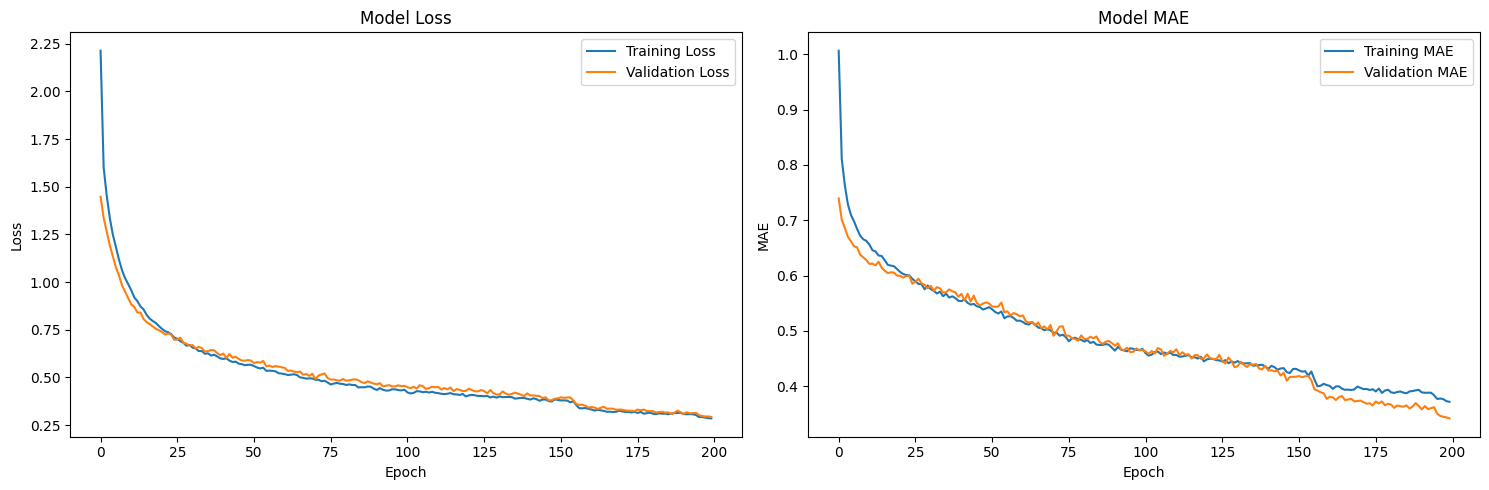

In [21]:
def run_temperature_humidity_forecasting(df):
    """Run dedicated humidity forecasting"""
    print("🌡️ DEDICATED MINIMUM HUMIDITY LSTM FORECASTING")
    print("=" * 70)
    
    # Initialize model
    model = HumidityMinLSTM(df, sequence_length=10, forecast_horizon=3)
    
    # Preprocess data
    model.preprocess_data()
    
    # Train model
    results, history, y_true, y_pred = model.train_model(
        validation_split=0.2, 
        epochs=200, 
        batch_size=64
    )
    
    # Plot training history
    model.plot_training_history(history)
    
    return model, results, history, y_true, y_pred

# Usage example:
model, results, history, y_true, y_pred = run_temperature_humidity_forecasting(df)



🔮 Making 3-day Minimum humidity forecast...
--------------------------------------------------
📅 3-Day Minimum Humidity Forecast:
  Thursday   (2025-05-01):
     🌡️ relative_humidity_2m_min (%): 31.77
  Friday     (2025-05-02):
     🌡️ relative_humidity_2m_min (%): 35.51
  Saturday   (2025-05-03):
     🌡️ relative_humidity_2m_min (%): 35.06


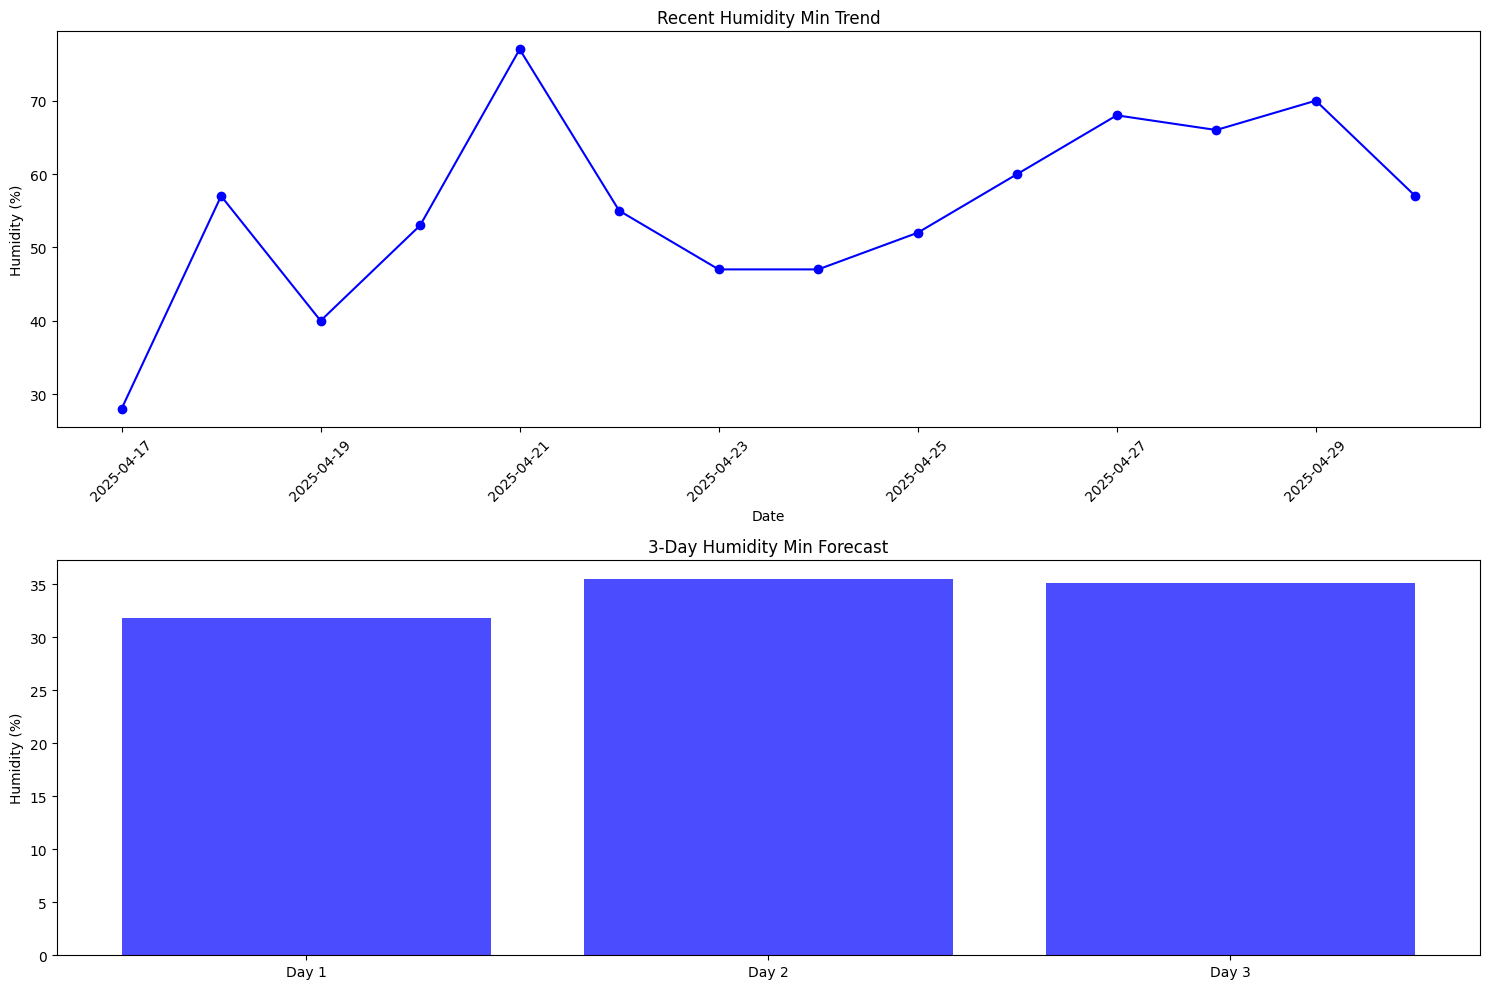

In [22]:
def make_predictions_and_visualize(model, df):
    """Make predictions and create visualizations for min humidity only"""
    import matplotlib.pyplot as plt
    from datetime import timedelta
    import pandas as pd
    import numpy as np
    
    print("\n🔮 Making 3-day Minimum humidity forecast...")
    print("-" * 50)
    
    # Get only the features used during training
    feature_cols = model.feature_cols

    # Pull only the last `sequence_length` rows
    recent_data = df[feature_cols].tail(model.sequence_length).copy()

    # Ensure numeric and same dtype
    recent_data = recent_data.apply(pd.to_numeric, errors='coerce').dropna()

    # If any rows dropped, re-pad from the top
    if len(recent_data) < model.sequence_length:
        padding_needed = model.sequence_length - len(recent_data)
        padding = np.zeros((padding_needed, len(feature_cols)))
        recent_data = np.vstack([padding, recent_data.values])
    else:
        recent_data = recent_data.values

    # Final shape must be (1, sequence_length, num_features)
    recent_data = recent_data.reshape(1, model.sequence_length, len(feature_cols)).astype(np.float32)

    try:
        # Get temperature/humidity predictions
        temp_humidity_results = model.predict_future(recent_data)
        
        # Get next 3 days
        last_date = pd.to_datetime(df['date']).max()
        next_3_dates = [last_date + timedelta(days=i+1) for i in range(3)]
        days_and_dates = [(d.strftime('%A'), d.strftime('%Y-%m-%d')) for d in next_3_dates]
        
        print("📅 3-Day Minimum Humidity Forecast:")
        for i, (day, date) in enumerate(days_and_dates):
            print(f"  {day:10} ({date}):")
            for target_name in model.available_targets:
                value = temp_humidity_results[target_name][i]
                print(f"     🌡️ {target_name}: {value:.2f}")
        
        # Visualization
        fig, axes = plt.subplots(2, 1, figsize=(15, 10))
        
        # Plot recent humidity trends
        if 'relative_humidity_2m_min (%)' in df.columns:
            recent_humidity = df[['date', 'relative_humidity_2m_min (%)']].tail(14)
            recent_humidity['date'] = pd.to_datetime(recent_humidity['date'])
            axes[0].plot(recent_humidity['date'], recent_humidity['relative_humidity_2m_min (%)'], 'o-', color='blue')
            axes[0].set_title('Recent Humidity Min Trend')
            axes[0].set_xlabel('Date')
            axes[0].set_ylabel('Humidity (%)')
            axes[0].tick_params(axis='x', rotation=45)
        
        # Plot forecast temperature
        forecast_days = [f"Day {i+1}" for i in range(3)]
        
        # Plot forecast humidity
        if 'relative_humidity_2m_min (%)' in temp_humidity_results:
            humidity_forecast = temp_humidity_results['relative_humidity_2m_min (%)']
            axes[1].bar(forecast_days, humidity_forecast, color='blue', alpha=0.7)
            axes[1].set_title('3-Day Humidity Min Forecast')
            axes[1].set_ylabel('Humidity (%)')
        
        plt.tight_layout()
        plt.show()
        
        return temp_humidity_results
        
    except Exception as e:
        print(f"❌ Prediction error: {e}")
        return None


# Usage example:

predictions = make_predictions_and_visualize(model, df)


🌡️ MINIMUM HUMIDITY PREDICTIONS

📅 Test Sequence 1:
------------------------------------------------------------

🌡️  relative_humidity_2m_min (%):
----------------------------------------
  Day |     Actual |  Predicted |      Error |    % Error
------------------------------------------------------------
    1 |      31.00 |      30.17 |       0.83 |       2.7%
    2 |      31.00 |      30.60 |       0.40 |       1.3%
    3 |      30.00 |      31.02 |       1.02 |       3.4%
------------------------------------------------------------
Sequence MAE: 0.751

📅 Test Sequence 2:
------------------------------------------------------------

🌡️  relative_humidity_2m_min (%):
----------------------------------------
  Day |     Actual |  Predicted |      Error |    % Error
------------------------------------------------------------
    1 |      54.00 |      51.04 |       2.96 |       5.5%
    2 |      42.00 |      41.52 |       0.48 |       1.1%
    3 |      32.00 |      34.72 |       2.72 

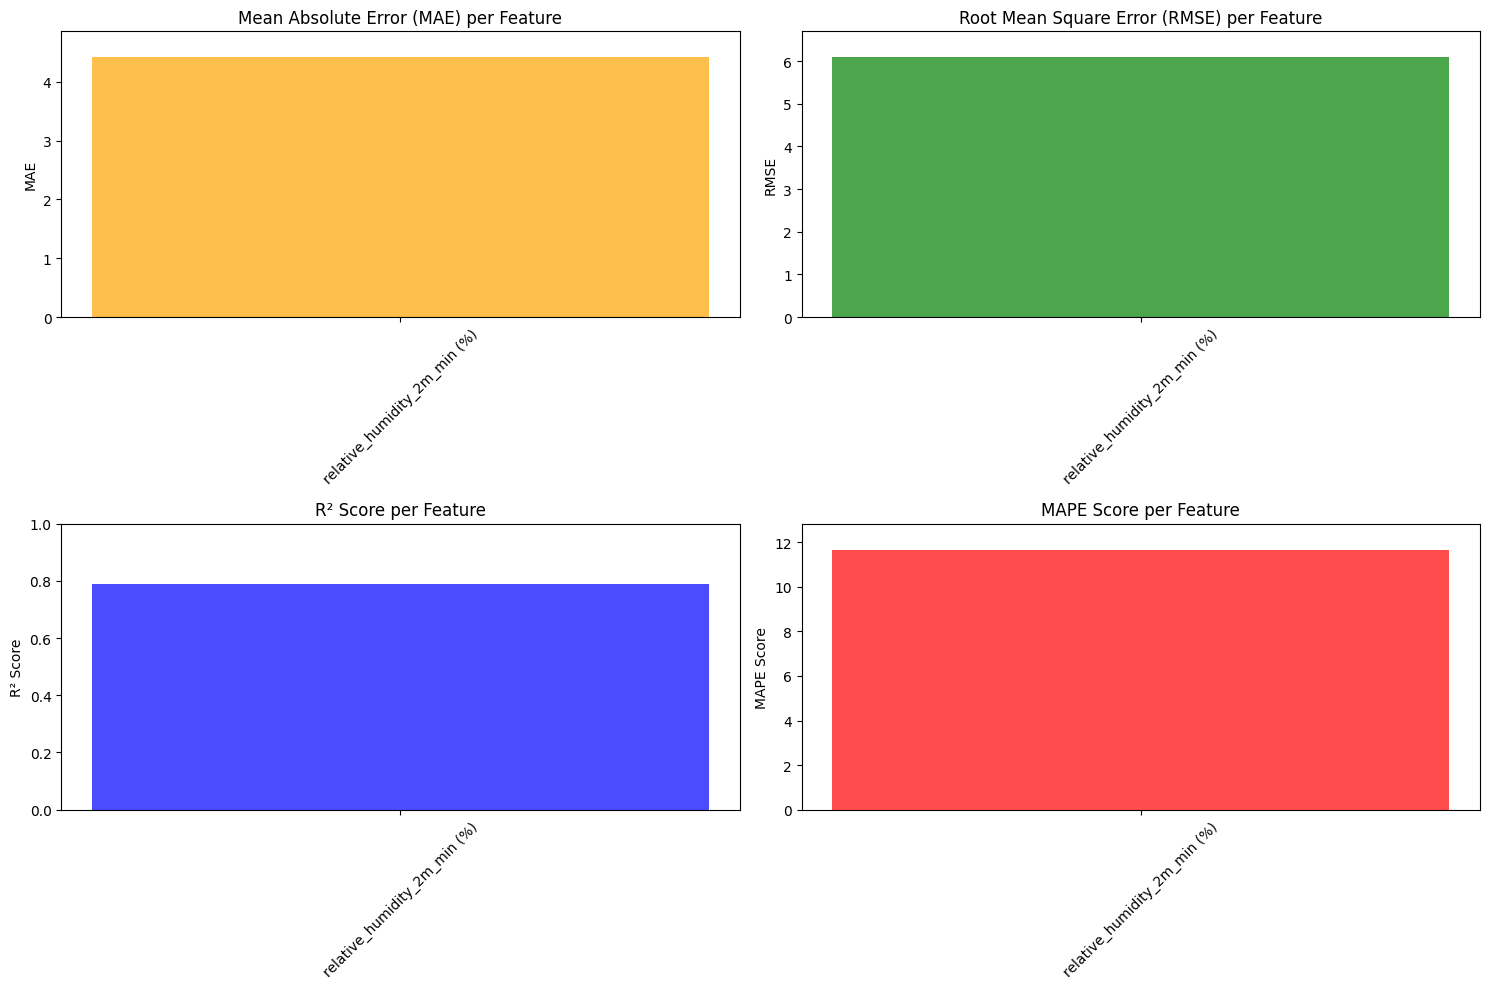


🏆 PERFORMANCE SUMMARY:
Best performing feature: relative_humidity_2m_min (%) (MAE: 4.414)
Worst performing feature: relative_humidity_2m_min (%) (MAE: 4.414)
Overall average MAE: 4.414
Overall average RMSE: 6.088
Overall average R²: 0.790


In [23]:
def show_regression_predictions(
    model, 
    y_true, 
    y_pred, 
    num_samples=5
):
    """Display humidity regression predictions only."""
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    print("🌡️ MINIMUM HUMIDITY PREDICTIONS")
    print("=" * 60)

    sample_size = min(num_samples, len(y_true))

    # Get feature names from the model
    feature_names = model.available_targets if hasattr(model, 'available_targets') else [f"Feature {i}" for i in range(y_true.shape[2])]

    # Display sample predictions
    for i in range(sample_size):
        print(f"\n📅 Test Sequence {i+1}:")
        print("-" * 60)

        # Create a nice table format for each feature
        for f, feature_name in enumerate(feature_names):
            print(f"\n🌡️  {feature_name}:")
            print("-" * 40)
            print(f"{'Day':>5} | {'Actual':>10} | {'Predicted':>10} | {'Error':>10} | {'% Error':>10}")
            print("-" * 60)

            mae_sequence = 0
            for day in range(model.forecast_horizon):
                actual = y_true[i, day, f]
                predicted = y_pred[i, day, f]
                error = abs(actual - predicted)
                percent_error = (error / (abs(actual) + 1e-8)) * 100
                mae_sequence += error

                print(f"{day+1:>5} | {actual:>10.2f} | {predicted:>10.2f} | {error:>10.2f} | {percent_error:>9.1f}%")

            mae_sequence /= model.forecast_horizon
            print("-" * 60)
            print(f"Sequence MAE: {mae_sequence:.3f}")

    # Overall statistics for temperature and humidity
    print(f"\n📊 OVERALL REGRESSION STATISTICS:")
    print("=" * 50)

    num_features = y_true.shape[2]

    for f, feature_name in enumerate(feature_names):
        print(f"\n🌡️  {feature_name}:")
        print("-" * 30)
        
        # Calculate metrics for this feature
        y_true_flat = y_true[:, :, f].flatten()
        y_pred_flat = y_pred[:, :, f].flatten()
        
        mae = mean_absolute_error(y_true_flat, y_pred_flat)
        rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
        r2 = r2_score(y_true_flat, y_pred_flat)
        mape = np.mean(np.abs((y_true_flat - y_pred_flat) / (y_true_flat + 1e-8))) * 100
        
        print(f"  MAE:  {mae:.3f}")
        print(f"  RMSE: {rmse:.3f}")
        print(f"  R²:   {r2:.3f}")
        print(f"  MAPE: {mape:.2f}%")
        
        # Per-day accuracy for this feature
        print(f"\n  📈 Daily Performance:")
        for day in range(model.forecast_horizon):
            day_true = y_true[:, day, f]
            day_pred = y_pred[:, day, f]
            day_mae = mean_absolute_error(day_true, day_pred)
            day_rmse = np.sqrt(mean_squared_error(day_true, day_pred))
            day_r2 = r2_score(day_true, day_pred)
            print(f"    Day {day+1}: MAE={day_mae:.3f}, RMSE={day_rmse:.3f}, R²={day_r2:.3f}")

    # Create visualization
    print(f"\n📈 CREATING PERFORMANCE VISUALIZATION...")
    
    # Calculate metrics for plotting
    maes = []
    rmses = []
    r2s = []
    mape = []
    
    for f in range(num_features):
        y_true_flat = y_true[:, :, f].flatten()
        y_pred_flat = y_pred[:, :, f].flatten()
        
        maes.append(mean_absolute_error(y_true_flat, y_pred_flat))
        rmses.append(np.sqrt(mean_squared_error(y_true_flat, y_pred_flat)))
        r2s.append(r2_score(y_true_flat, y_pred_flat))
        mape.append(np.mean(np.abs((y_true_flat - y_pred_flat) / (y_true_flat + 1e-8))) * 100)

    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # MAE plot
    axes[0, 0].bar(feature_names, maes, color='orange', alpha=0.7)
    axes[0, 0].set_title("Mean Absolute Error (MAE) per Feature")
    axes[0, 0].set_ylabel("MAE")
    axes[0, 0].set_ylim(0, max(maes) * 1.1)
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # RMSE plot
    axes[0, 1].bar(feature_names, rmses, color='green', alpha=0.7)
    axes[0, 1].set_title("Root Mean Square Error (RMSE) per Feature")
    axes[0, 1].set_ylabel("RMSE")
    axes[0, 1].set_ylim(0, max(rmses) * 1.1)
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # R² plot
    axes[1, 0].bar(feature_names, r2s, color='blue', alpha=0.7)
    axes[1, 0].set_title("R² Score per Feature")
    axes[1, 0].set_ylabel("R² Score")
    axes[1, 0].set_ylim(0, max(1.0, max(r2s) * 1.1))
    axes[1, 0].tick_params(axis='x', rotation=45)
    

    axes[1, 1].bar(feature_names, mape, color='red', alpha=0.7)
    axes[1, 1].set_title("MAPE Score per Feature")
    axes[1, 1].set_ylabel("MAPE Score")
    axes[1, 1].set_ylim(0, max(mape) * 1.1)
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    
    plt.tight_layout()
    plt.show()

    # Summary statistics
    print(f"\n🏆 PERFORMANCE SUMMARY:")
    print("=" * 30)
    print(f"Best performing feature: {feature_names[np.argmin(maes)]} (MAE: {min(maes):.3f})")
    print(f"Worst performing feature: {feature_names[np.argmax(maes)]} (MAE: {max(maes):.3f})")
    print(f"Overall average MAE: {np.mean(maes):.3f}")
    print(f"Overall average RMSE: {np.mean(rmses):.3f}")
    print(f"Overall average R²: {np.mean(r2s):.3f}")


# Usage example - replace your original function call with this:
show_regression_predictions(
    model, 
    y_true, 
    y_pred, 
    num_samples=3
)

In [24]:
def save_lstm_model(model, model_name="HumidityMinLSTM", save_dir="saved_models"):
    import os
    import json
    import pickle
    from datetime import datetime
    import joblib

    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_folder = f"{save_dir}/{model_name.replace(' ', '_')}_{timestamp}"
    os.makedirs(model_folder, exist_ok=True)

    print(f"💾 Saving '{model_name}' to: {model_folder}")
    print("=" * 60)

    try:
        # 1. Save the Keras model
        model_path = f"{model_folder}/keras_model.keras"
        model.model.save(model_path)
        print("✅ Keras model saved.")

        # 2. Save scalers
        joblib.dump(model.scaler_features, f"{model_folder}/scaler_features.pkl")
        joblib.dump(model.scaler_targets, f"{model_folder}/scaler_targets.pkl")
        print("✅ Scalers saved.")

        # 3. Save config
        config = {
            'model_name': model_name,
            'sequence_length': model.sequence_length,
            'forecast_horizon': model.forecast_horizon,
            'available_targets': model.available_targets,
            'feature_columns': model.feature_cols,
            'timestamp': timestamp,
            'model_type': 'HumidityMinLSTM',
            'framework': 'TensorFlow/Keras'
        }
        with open(f"{model_folder}/model_config.json", 'w') as f:
            json.dump(config, f, indent=4)
        print("✅ Model configuration saved.")

        # 4. Save model object (without keras model to avoid issues)
        model_copy = model.__dict__.copy()
        model_copy.pop('model', None)
        with open(f"{model_folder}/full_model.pkl", 'wb') as f:
            pickle.dump(model_copy, f)
        print("✅ Full model object saved.")

        return model_folder

    except Exception as e:
        print(f"❌ Error saving model: {e}")
        return None



def load_lstm_model(model_folder):
    import os
    import json
    import pickle
    import joblib
    from tensorflow.keras.models import load_model

    try:
        print(f"📂 Loading model from: {model_folder}")

        # Load keras model
        keras_model = load_model(f"{model_folder}/keras_model.keras")

        # Load scalers
        scaler_features = joblib.load(f"{model_folder}/scaler_features.pkl")
        scaler_targets = joblib.load(f"{model_folder}/scaler_targets.pkl")

        # Load config
        with open(f"{model_folder}/model_config.json", 'r') as f:
            config = json.load(f)

        # Load full model dict
        with open(f"{model_folder}/full_model.pkl", 'rb') as f:
            model_dict = pickle.load(f)

        # Create empty model object
        model = HumidityMinLSTM(pd.DataFrame(), config['sequence_length'], config['forecast_horizon'])
        model.model = keras_model
        model.scaler_features = scaler_features
        model.scaler_targets = scaler_targets

        # Restore other attributes
        for key, value in model_dict.items():
            setattr(model, key, value)

        print(f"✅ Model '{config['model_name']}' successfully loaded!")
        return model

    except Exception as e:
        print(f"❌ Error loading model: {e}")
        return None


model_folder = save_lstm_model(model, model_name="MinimumHumidityLSTM_Model1")

💾 Saving 'MinimumHumidityLSTM_Model1' to: saved_models/MinimumHumidityLSTM_Model1_20250706_163357
✅ Keras model saved.
✅ Scalers saved.
✅ Model configuration saved.
✅ Full model object saved.
